In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.metrics as skm
from scipy.stats import ks_2samp
import math
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

# catboost
try:
    import catboost as cb
except:
    ! pip install catboost
    import catboost as cb

# xg boost
try:
    import xgboost as xbm
except:
    ! pip install xgboost
    import xgboost as xbm

(CVXPY) Dec 17 09:52:41 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Dec 17 09:52:41 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


#### Functions

In [2]:
def target_by_data_set(df, str_target):
    df_tmp = df.groupby(by='data_set', as_index=False).agg({
        str_target: 'mean',
    })
    df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
    df_tmp.sort_values(by='sort', ascending=True, inplace=True)
    df_tmp.drop('sort', axis=1, inplace=True)

    # plot
    x = df_tmp['data_set']
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by Data Set')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [3]:
def target_by_feature(df, str_col, str_target):
    df_tmp = df[df['data_set'] == 'train'].groupby(by=str_col, as_index=False).agg({
        str_target: 'mean',
    })

    # plot
    x = df_tmp[str_col].astype(str)
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_col}')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [4]:
def target_by_feature_quantile(df, str_col, int_n_quantiles, str_target):
    # get quantile
    df_tmp = df[df['data_set'] == 'train'].copy()
    # replace infs with nan
    df_tmp[str_col] = df_tmp[str_col].replace(np.inf, np.nan)
    # drop missing rows
    df_tmp = df_tmp.dropna(subset=[str_col])
    # get quantile
    df_tmp['quantile'] = pd.qcut(df_tmp[str_col], q=int_n_quantiles, duplicates='drop')
    # min-max
    df_tmp['min'] = df_tmp[str_col]
    df_tmp['max'] = df_tmp[str_col]
    # get target mean by quangtile
    df_tmp = df_tmp.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'max': 'max',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'{str_target} by {str_col} Quantile')
    ax.set_xlabel(f'{str_col} Quantile')
    ax.set_ylabel(str_target)
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target])
    plt.show()

In [5]:
def get_suggested_constraints(df, list_cols_model, str_target, int_n_quantiles):
    list_dict_row = []
    for col in tqdm(list_cols_model):
        # df_tmp
        df_tmp = df.copy()
        # replace infs with nan
        df_tmp[col] = df_tmp[col].replace(np.inf, np.nan)
        # drop missing rows
        df_tmp = df_tmp.dropna(subset=[col])
        # get number of unique values
        int_n_unique = df_tmp[col].nunique()
        # logic
        if int_n_unique <= int_n_quantiles:
            # create a feature named quantile
            df_tmp['quantile'] = df_tmp[str_col]
        else:
            # get quantile
            df_tmp['quantile'] = pd.qcut(df_tmp[col], q=int_n_quantiles, duplicates='drop')
        # min-max
        df_tmp['min'] = df_tmp[col]
        df_tmp['max'] = df_tmp[col]
        # get target mean by quangtile
        df_tmp = df_tmp.groupby(by='quantile', as_index=False).agg({
            'min': 'min',
            'max': 'max',
            str_target: 'mean',
        })
        # sort
        df_tmp.sort_values(by='min', ascending=True, inplace=True)
        # create rank column
        df_tmp['rank'] = range(1, df_tmp.shape[0]+1)
        # fit trend line
        try:
            flt_slope, flt_intercept = np.polyfit(x=df_tmp['rank'], y=df_tmp[str_target], deg=1)
        except:
            flt_slope = 0
            flt_intercept = 0
        # logic for monotone contraints
        if flt_slope > 0:
            int_constraint = 1
            str_imputation = 'max'
        elif flt_slope < 0:
            int_constraint = -1
            str_imputation = 'min'
        else:
            int_constraint = 0
            str_imputation = 'none'
        # make a row
        dict_row = {
            'feature': col,
            'intercept': flt_intercept,
            'slope': flt_slope,
            'constraint': int_constraint,
            'imputation': str_imputation,
        }
        list_dict_row.append(dict_row)
    # make a df
    df = pd.DataFrame(list_dict_row)
    # return
    return df

In [6]:
class OverSampling:
    def __init__(self, df, str_target, flt_target_value, flt_current_value):
        self.df = df
        self.str_target = str_target
        self.flt_target_value = flt_target_value
        self.flt_current_value = flt_current_value
    # oversample zeros
    def oversample_zeros(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for the new n total to reach target
        int_n_total_new = math.ceil(int_n_ones_original / flt_target_value)
        # get n additional 0s
        int_n_additional_zeros = int_n_total_new - int_n_ones_original - int_n_zeros_original
        # get sample
        df_zeros_additional = df_zeros.sample(n=int_n_additional_zeros, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_zeros_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df 
    # undersample ones
    def oversample_ones(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for number of 1s
        int_n_additional_ones = math.ceil((int_n_ones_original - (flt_target_value * int_n_total_original)) / (flt_target_value - 1))
        # get sample
        df_ones_additional = df_ones.sample(n=int_n_additional_ones, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_ones_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df
    # sample
    def sample(self):
        # logic
        if self.flt_target_value < self.flt_current_value:
            df = self.oversample_zeros()
        else:
            df = self.oversample_ones()
        # return
        return df

In [7]:
# get xgb feat importance
def get_xgboost_feat_importance(cls_model_inference):
    cls_booster = cls_model_inference.get_booster()
    dict_feat_imp = cls_booster.get_score(importance_type='gain')
    ser_feat_imp = pd.Series(dict_feat_imp)
    df_tmp = ser_feat_imp.reset_index()
    df_tmp.columns = ['feature', 'importance']
    df_tmp.sort_values(by='importance', ascending=False, inplace=True)
    return df_tmp

In [8]:
def get_catboost_feat_importance(cls_model_inference, pool_eval):
    df_tmp = cls_model_inference.get_feature_importance(
        data=pool_eval,
        type='LossFunctionChange',
        prettified=True,
    )
    df_tmp.columns = ['feature', 'importance']
    df_tmp.sort_values(by='importance', ascending=False, inplace=True)
    return df_tmp

In [9]:
def get_logistic_regression_feat_importance(df, cls_model_inference, list_cols_model=None):
    try:
        list_cols_model = list(cls_model_inference.feature_names_in_)
    except:
        pass
    df_tmp = pd.DataFrame({
        'feature': list_cols_model,
        'importance': list(cls_model_inference.coef_[0]),
    })
    # make into dictionary
    dict_coef = dict(zip(df_tmp['feature'], df_tmp['importance']))
    # subset df
    df_tmp = df[list_cols_model].copy()
    # iterate
    for key, val in dict_coef.items():
        # multiply the feature by the coefficient
        df_tmp[key] = df_tmp[key] * val
    # get the mean for each
    list_dict_row = []
    for col in list_cols_model:
        flt_mean = df_tmp[col].mean()
        dict_row = {
            'feature': col,
            'importance': flt_mean,
        }
        list_dict_row.append(dict_row)
    # make df
    df_tmp = pd.DataFrame(list_dict_row)
    # make abs value
    df_tmp['importance_abs'] = df_tmp['importance'].apply(abs)
    # sort    
    df_tmp.sort_values(by='importance_abs', ascending=False, inplace=True)
    # return
    return df_tmp

In [10]:
# min max scale
def min_max_scale(ser_values):
    # get min
    flt_min = ser_values.min()
    # get max
    flt_max = ser_values.max()
    # range
    flt_range = flt_max - flt_min
    # subtract min
    ser_values = ser_values - flt_min
    # divide by range
    ser_values = ser_values / flt_range
    # return
    return ser_values

In [11]:
def get_scaled_score(df):
    df['flt_eval_metric_valid_scaled'] = min_max_scale(df['flt_eval_metric_valid'])
    df['diff'] = df['flt_eval_metric_train'] - df['flt_eval_metric_valid']
    df['diff_scaled'] = 1 - min_max_scale(df['diff'])
    df['n_feats_scaled'] = 1 - min_max_scale(df['n_feats'])
    list_cols = [
        'flt_eval_metric_valid_scaled',
        'diff_scaled',
        #'n_feats_scaled',
    ]
    df['score'] = df[list_cols].mean(axis=1)
    df.sort_values(by='score', ascending=False, inplace=True)
    return df

In [12]:
# get shap values
def get_shap(cls_model_inference, X, list_cols_model):
    cls_explainer = shap.Explainer(cls_model_inference)
    df_tmp = pd.DataFrame(
        cls_explainer.shap_values(X[list_cols_model]),
        columns=list_cols_model,
    )
    # get avg by col
    ser_mean = df_tmp.mean()
    df_tmp = ser_mean.reset_index()
    df_tmp.columns = ['feature','importance']
    df_tmp['importance'] = df_tmp['importance'].apply(abs)
    # sort
    df_tmp.sort_values(by='importance', ascending=False, inplace=True)
    # return
    return df_tmp

In [13]:
# ks
def get_ks_score(y_true, y_pred):
    # make df
    df_tmp = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred,
    })
    # get mean of y_true
    flt_mean = df_tmp['y_true'].mean()
    # sort
    df_tmp.sort_values(by='y_pred', ascending=False, inplace=True)
    # make row number
    df_tmp['row'] = range(1, df_tmp.shape[0]+1)
    df_tmp['prop_row'] = df_tmp['row'] / df_tmp.shape[0]
    df_tmp['yhat_class'] = df_tmp['y_pred'].apply(
        lambda x: 1 if x <= flt_mean else 0,
    )
    # separate predictions by true class
    ser_pos_scores = df_tmp[df_tmp['y_true'] == 1]['yhat_class']
    ser_neg_scores = df_tmp[df_tmp['y_true'] == 0]['yhat_class']
    # Calculate KS statistic
    ks_stat, p_value = ks_2samp(ser_pos_scores, ser_neg_scores)
    return ks_stat

In [14]:
def evaluate(y_train, list_predictions_train, y_test, list_predictions_test, y_holdout, list_predictions_holdout):
    # get auc
    flt_auc_train = skm.roc_auc_score(
        y_true=y_train,
        y_score=list_predictions_train,
    )
    print(f'AUC Train: {flt_auc_train:0.4f}')
    flt_auc_test = skm.roc_auc_score(
        y_true=y_test,
        y_score=list_predictions_test,
    )
    print(f'AUC Test: {flt_auc_test:0.4f}')
    flt_auc_holdout = skm.roc_auc_score(
        y_true=y_holdout,
        y_score=list_predictions_holdout,
    )
    print(f'AUC Holdout: {flt_auc_holdout:0.4f}')
    print()
    # logloss
    flt_logloss_train = skm.log_loss(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'Logloss Train: {flt_logloss_train:0.4f}')
    flt_logloss_test = skm.log_loss(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'Logloss Test: {flt_logloss_test:0.4f}')
    flt_logloss_holdout = skm.log_loss(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'Logloss Holdout: {flt_logloss_holdout:0.4f}')
    print()
    # ks
    flt_ks_train = get_ks_score(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'KS Train: {flt_ks_train:0.4f}')
    flt_ks_test = get_ks_score(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'KS Test: {flt_ks_test:0.4f}')
    flt_ks_holdout = get_ks_score(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'KS Holdout: {flt_ks_holdout:0.4f}')
    return flt_auc_train

In [15]:
def get_directions_of_predictions(X, list_predictions, str_target, list_actual, list_cols, int_n_quantiles):
    # assign predictions
    X['yhat'] = list_predictions
    # assign actual
    X[str_target] = list_actual
    # iterate and plot
    for col in tqdm(list_cols):
        # get number of unique values
        int_n_unique = X[col].nunique()
        # logic
        if int_n_unique <= int_n_quantiles:
            # create a feature named quantile
            X['quantile'] = X[col]
        else:
            # get quantile
            X['quantile'] = pd.qcut(X[col], q=int_n_quantiles, duplicates='drop')
        # get target mean by quantile
        X['min'] = X[col]
        # group
        df_tmp = X.groupby(by='quantile', as_index=False).agg({
            'min': 'min',
            'yhat': 'mean',
            str_target: 'mean',
            
        })
        # sort
        df_tmp.sort_values(by='min', ascending=True, inplace=True)
        # rank
        df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
        # plot
        fig, ax = plt.subplots(figsize=(9,5))
        ax.set_title(f'Mean Predicted and Actual by {col} Quantile')
        ax.set_xlabel(f'{col} Quantile')
        ax.set_ylabel(str_target)
        # predicted
        ax.plot(df_tmp['quantile'].astype(str), df_tmp['yhat'], label='Predicted')
        # actual
        ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target], label='Actual')
        # legend
        ax.legend()
        # show
        plt.show()

In [16]:
def get_directions_of_predictions_for_scorecard(X, list_predictions, str_target, list_actual, list_cols, df_bins):
    # assign predictions
    X['yhat'] = list_predictions
    # assign actual
    X[str_target] = list_actual
    # iterate and plot
    for col in tqdm(list_cols):
        # map bin label
        df_bins_tmp = df_bins[df_bins['feature'] == col].copy()
        # create dict
        dict_map_bin = dict(zip(df_bins_tmp['bin'], df_bins_tmp['bin_label']))
        # map
        X['bin_label'] = X[col].map(dict_map_bin)
        # group
        df_tmp = X.groupby(by='bin_label', as_index=False).agg({
            'yhat': 'mean',
            str_target: 'mean',
            
        })
        # sort
        df_tmp.sort_values(by='bin_label', ascending=True, inplace=True)
        # plot
        fig, ax = plt.subplots(figsize=(9,5))
        ax.set_title(f'Mean Predicted and Actual by {col} Bin (Ascending)')
        ax.set_xlabel(f'{col} Bin')
        ax.set_ylabel(str_target)
        # predicted
        ax.plot(df_tmp['bin_label'].astype(str), df_tmp['yhat'], label='Predicted')
        # actual
        ax.plot(df_tmp['bin_label'].astype(str), df_tmp[str_target], label='Actual')
        # legend
        ax.legend()
        # show
        plt.show()

In [17]:
def get_mean_actual_by_prediction_quantile(X, list_predictions, list_actual, str_target, int_n_quantiles, str_model_type):
    # assign
    X['yhat'] = list_predictions
    X[str_target] = list_actual
    # get quantile
    X['quantile'] = pd.qcut(X['yhat'], q=int_n_quantiles, duplicates='drop')
    # get min
    X['min'] = X['yhat']
    X['predicted'] = X['yhat']
    # group
    df_tmp = X.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'predicted': 'mean',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # create rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_model_type} Prediction Quantile')
    ax.set_xlabel('Prediction Quantile')
    ax.set_ylabel(f'Mean {str_target}')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target], label='Actual')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp['predicted'], label='Predicted')
    # legend
    ax.legend()
    # show
    plt.show()

In [18]:
def remove_multicollinearity(X, list_cols_model, dict_map_importance, flt_threshold):
    list_dict_row = []
    a = 0
    for col1 in tqdm(list_cols_model):
        # temporary list
        list_tmp = list_cols_model[a+1:].copy()
        for col2 in list_tmp:
            # get correlation
            x = X[col1]
            y = X[col2]
            flt_r, flt_p = spearmanr(x, y)
            # row
            dict_row = {
                'col1': col1,
                'col2': col2,
                'r': flt_r,
            }
            # append
            list_dict_row.append(dict_row)
        # add 1
        a += 1
    # make df
    df_tmp = pd.DataFrame(list_dict_row)
    # make absolute value
    df_tmp['r_abs'] = df_tmp['r'].apply(abs)
    # map importance
    df_tmp['col1_importance'] = df_tmp['col1'].map(dict_map_importance)
    df_tmp['col2_importance'] = df_tmp['col2'].map(dict_map_importance)
    # flag high correlation
    df_tmp['high_correlation'] = df_tmp['r_abs'].apply(
        lambda x: 1 if x >= flt_threshold else 0,
    )
    # subset
    df_tmp = df_tmp[df_tmp['high_correlation'] == 1].copy()
    # select feature to remove
    df_tmp['remove_feature'] = df_tmp.apply(
        lambda x: x['col2'] if x['col1_importance'] > x['col2_importance']  else x['col1'],
        axis=1,
    )
    # get feats to rm
    list_cols_remove = list(df_tmp['remove_feature'])
    # rm dups
    list_cols_remove = list(dict.fromkeys(list_cols_remove))
    # return
    return df_tmp, list_cols_remove

In [19]:
def bin_features(list_cols, X_train, y_train, X_test, X_holdout, dict_monotone_constraints):
    dict_bins = {}
    list_cols_scorecard = []
    for col in tqdm(list_cols):
        # get the monotonicity
        int_monotonicity = dict_monotone_constraints[col]
        # logic
        if int_monotonicity == -1:
            str_monotonic_trend = 'descending'
        else:
            str_monotonic_trend = 'ascending'
        # init
        cls_binning = OptimalBinning(
            name=col,
            dtype='numerical',
            solver='cp',
            monotonic_trend=str_monotonic_trend,
        )
        # fit
        cls_binning.fit(
            X_train[col],
            y_train,
        )
        # assign
        dict_bins[col] = cls_binning
        # transform
        str_col = f'{col}_binned'
        X_train[str_col] = cls_binning.transform(
            X_train[col],
            metric='woe',
        )
        X_test[str_col] = cls_binning.transform(
            X_test[col],
            metric='woe',
        )
        X_holdout[str_col] = cls_binning.transform(
            X_holdout[col],
            metric='woe',
        )
        # append
        list_cols_scorecard.append(str_col)
    # return
    return dict_bins, list_cols_scorecard, X_train, X_test, X_holdout

#### Constants

In [20]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_target = f'Early_Pay_Delinquency_60_720_Flag'
print(f'Target: {str_target}')

str_dirname_output = './output'

# for ordering
dict_sort = {
    'train': 1,
    'valid': 2,
    'test': 3,
    'inform': 4,
    'holdout': 5,
}

# limit for proporiton nan
flt_threshold_nan = 0.50

int_n_iterations = 100
int_n_early_stopping = 5
int_max_depth = 1

# correlation threshold
flt_threshold = 0.70

Project: 20241112-simple-model-test
Task: 11_60_in_720_loss
Subtask: 02_model
Target: Early_Pay_Delinquency_60_720_Flag


#### Output directory

In [21]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Get data dictionary for mapping descriptions

In [22]:
str_filename = 'data_dictionary.csv'
str_local_path = f'../../data_dictionary/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
dict_map_descriptions = dict(zip(df_tmp['feature_name'], df_tmp['Description']))

#### Get TU scorecard features

In [23]:
str_filename = 'df_tu_scorecard_features.csv'
str_local_path = f'../../scorecard_features/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
# map description
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions)

# get features
list_cols_tu = list(df_tmp['feature'])
print(f'There are {len(list_cols_tu)} unique TU scorecard features')

# show
df_tmp

There are 51 unique TU scorecard features


,feature,1_open_bk,2_thick_and_dirty,3_thick_and_clean,4_thin,sum,description
0,g106s__tu,1.0,1.0,1.0,1.0,4.0,Months on file
1,balmag01__tu,0.0,1.0,1.0,1.0,3.0,Non-mortgage balance magnitude algorithm over ...
2,g251b__tu,0.0,1.0,1.0,1.0,3.0,Number of 60 days past due or worse items in t...
3,re01s__tu,0.0,1.0,1.0,1.0,3.0,Number of revolving trades
4,g232s__tu,1.0,0.0,1.0,0.0,2.0,Number of inquiries (includes duplicates)
5,rtl_trd__tu,1.0,0.0,0.0,1.0,2.0,Number of retail trades
6,au20s__tu,1.0,0.0,0.0,1.0,2.0,Months since oldest auto trade opened
7,p02g__tu,0.0,0.0,1.0,1.0,2.0,NaN
8,g213b__tu,0.0,1.0,1.0,0.0,2.0,Highest balance of non-medical third party col...
9,p02b__tu,1.0,0.0,1.0,0.0,2.0,NaN


#### Import data

In [24]:
list_cols_import = [
    'data_set',
    'days_on_books',
    'applicationdate__app',
    'accountid',
    'bitdebtor__app',
    str_target,
    'fltgrossmonthly__income_sum', # income
    'miles_odometer__app',
    'flt_payment_open__tu_pmthx',
    'ENG-franchise',
    'ENG-has_codebtor',
    'ENG-vehicle_age',
    'ENG-payment_to_income', # payment to income
    'ENG-loan_to_value', # loan to value
    'ENG-bk', # bk
    'dti__app', # debt to income
    # pmt hx
    'flt_mean_months_to_first_bad__tu_pmthx', # avg proportion of months to first bad pmt (low is bad)
    # open
    'flt_payment_open__tu_pmthx',
    'int_n_months_open__tu_pmthx',
    'flt_wtd_avg_open__tu_pmthx', # weighted avg of most recent open (low is bad)
    'flt_avg_open__tu_pmthx', # avg of most recent open (low is bad)
    'int_30dpd_open__tu_pmthx', # n times 30 dpd of most recent open
    'int_60dpd_open__tu_pmthx', # n times 60 dpd of most recent open
    'int_90dpd_open__tu_pmthx', # n times 90 dpd of most recent open
    # closed
    'int_n_months_closed__tu_pmthx',
    'flt_wtd_avg_closed__tu_pmthx',
    'flt_avg_closed__tu_pmthx',
    'int_30dpd_closed__tu_pmthx',
    'int_60dpd_closed__tu_pmthx',
    'int_90dpd_closed__tu_pmthx',
    # handpicked
    're01s__tu', # top feature in PD
    'g990s__tu', # highest shap in PD
    'g106s__tu', # in all 4 scorecards
    'addrinputtimenewest__ln', # Time on file (in months) since the subject was most recently reported at the input address
    'linka029__tu', # checking account inquiries
    'au25s__tu', # pmt hx
    'au27s__tu', # pmt hx
    'g980s__tu',
    'bkc321__tu',
    'balmag01__tu',
    'at28b__tu',
    'addrlastmovetaxratiodiff__ln',
    'at35a__tu',
    'g232s__tu', # top feature when using all features
    'g306s__tu',
    'au21s__tu',
    'addrinputproblems__ln',
    'linka006__tu',
    'inquiryshortterm12month__ln',
    'g234s__tu',
    'cv15__tu',
    'at21s__tu',
    'inquirybanking12month__ln',
    'g242s__tu',
    'paymnt11__tu',
    'inquirytelcom12month__ln',
    's073b__tu',
    's064b__tu',
    'linka017__tu',
    'g213a__tu',
    'derogseverityindex__ln',
]
# add tu
list_cols_import = list_cols_import + list_cols_tu
# rm dups
list_cols_import = list(dict.fromkeys(list_cols_import))
# import
list_str_filename = [
    'train',
    'valid',
    'test',
    'inform',
    'holdout',
]
list_df = []
for str_filename in tqdm(list_str_filename):
    str_filename_tmp = f'df_{str_filename}.gzip'
    str_uri = f's3://{str_project}/{str_task}/01_data_split/{str_filename_tmp}'
    df = pd.read_parquet(
        str_uri,
        columns=list_cols_import,
    )
    # logic
    if str_filename == 'valid':
        df['data_set'] = 'train'
    else:
        pass
    # append
    list_df.append(df)
# concatenate
df = pd.concat(list_df)
# save memory
del list_df
# show
df

100%|██████████| 5/5 [00:03<00:00,  1.60it/s]


,data_set,days_on_books,applicationdate__app,accountid,bitdebtor__app,Early_Pay_Delinquency_60_720_Flag,fltgrossmonthly__income_sum,miles_odometer__app,flt_payment_open__tu_pmthx,ENG-franchise,...,trv01__tu,aggs911__tu,au202s__tu,au34s__tu,bi21s__tu,bkc322__tu,ctc21__tu,ctm21__tu,in57s__tu,sl99b__tu
175,train,1215,2021-07-22 17:37:28.093,5716209,1,0,7157.0,28796.0,NaN,1,...,1.0,100.0,NaN,NaN,89.0,1.0,NaN,NaN,NaN,NaN
154,train,1215,2021-07-07 12:49:20.480,5702150,1,0,7662.0,41384.0,NaN,1,...,999.0,41.0,1.0,NaN,154.0,20.0,NaN,NaN,NaN,NaN
18,train,1218,2021-07-07 12:17:51.430,5702106,1,0,8286.1,22951.0,NaN,1,...,NaN,NaN,0.0,NaN,189.0,NaN,NaN,NaN,NaN,NaN
207,train,1215,2021-07-21 13:45:49.677,5714824,0,0,4415.0,36659.0,501.0,1,...,NaN,NaN,1.0,92.0,25.0,NaN,NaN,NaN,0.0,NaN
206,train,1215,2021-07-21 13:45:49.677,5714824,1,0,3461.0,36659.0,364.0,1,...,999.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42089,holdout,721,2022-11-28 12:25:18.957,6464887,1,0,4836.0,41431.0,NaN,1,...,3.0,95.0,2.0,NaN,NaN,160.0,NaN,NaN,NaN,NaN
42197,holdout,720,2022-11-28 11:17:53.530,6464638,1,0,3005.0,98954.0,NaN,0,...,999.0,68.0,0.0,NaN,51.0,303.0,NaN,NaN,0.0,NaN
41923,holdout,725,2022-11-28 10:17:32.573,6464416,1,0,4247.0,83840.0,713.0,0,...,1.0,NaN,2.0,37.0,NaN,NaN,NaN,NaN,0.0,NaN
42062,holdout,722,2022-11-28 15:09:59.617,6465473,1,0,4160.0,70856.0,NaN,1,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Target mean by data set

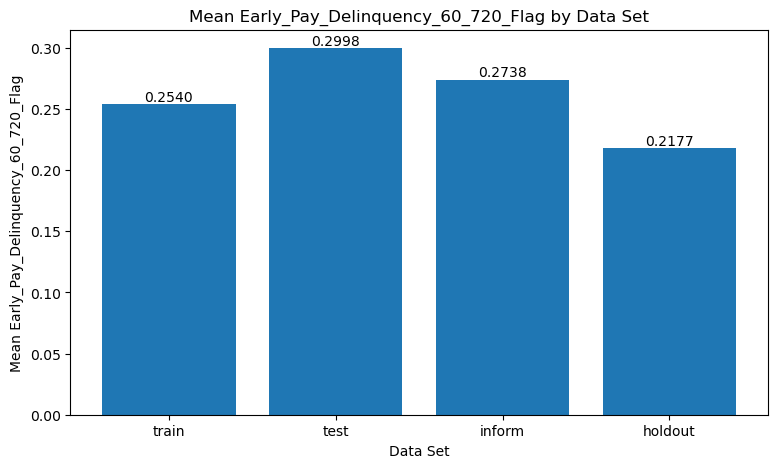

In [25]:
target_by_data_set(
    df=df,
    str_target=str_target,
)

#### Target mean by BK

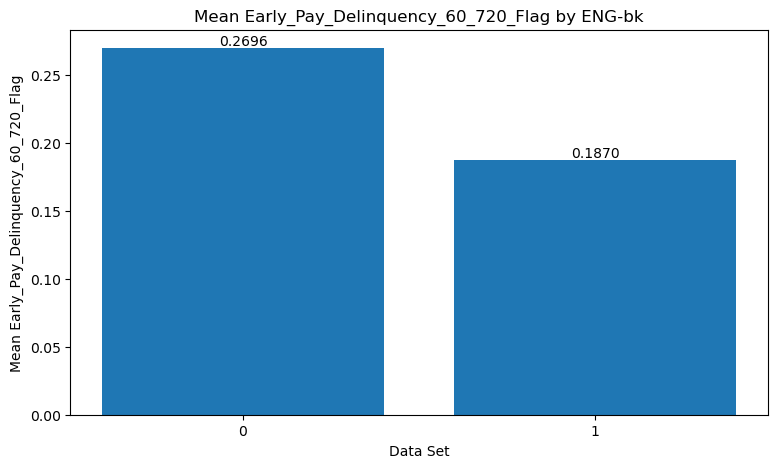

In [26]:
str_col = 'ENG-bk'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target mean by dealer type

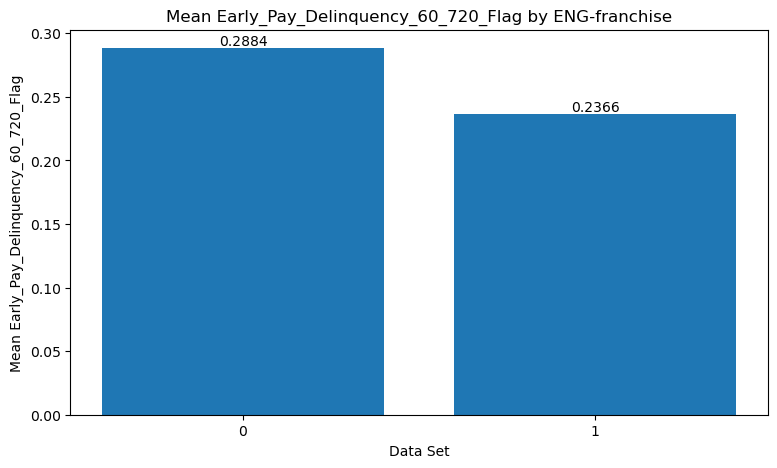

In [27]:
str_col = 'ENG-franchise'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target mean by has a codebtor

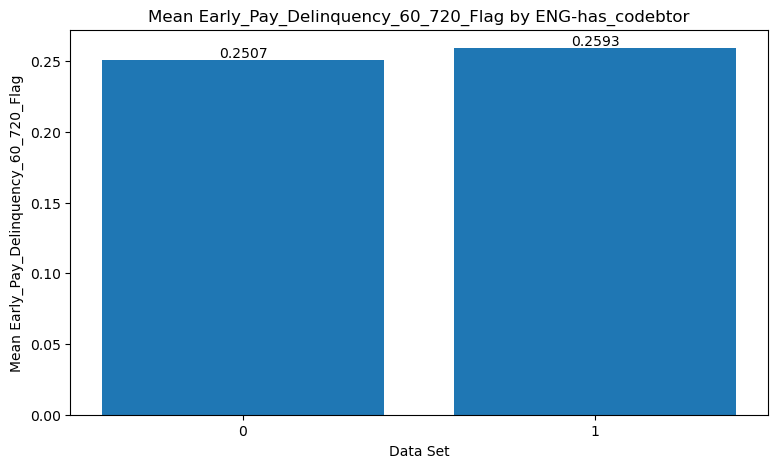

In [28]:
str_col = 'ENG-has_codebtor'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target by LTV Quantile

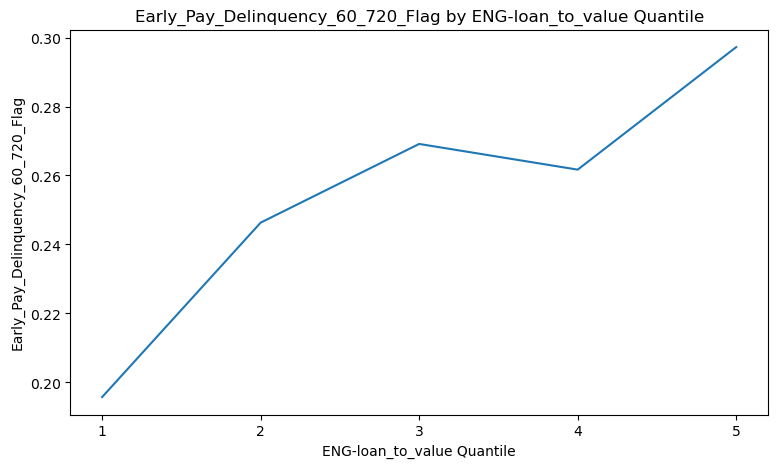

In [29]:
# get quantile
str_col = 'ENG-loan_to_value'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Target by income quantile

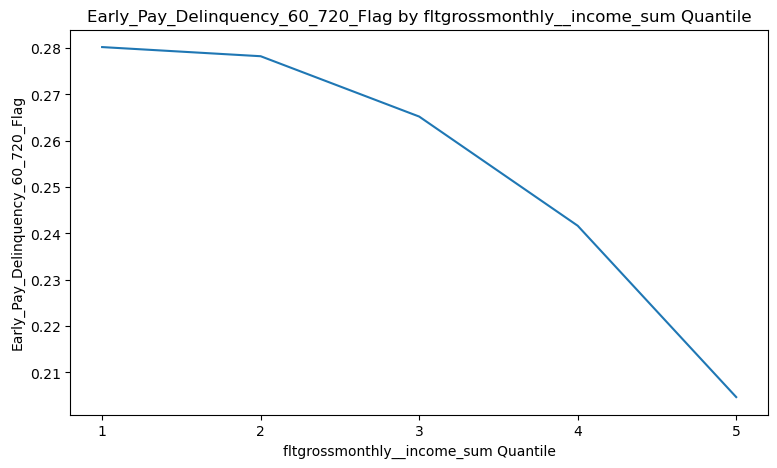

In [30]:
# get quantile
str_col = 'fltgrossmonthly__income_sum'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Target by PTI Quantile

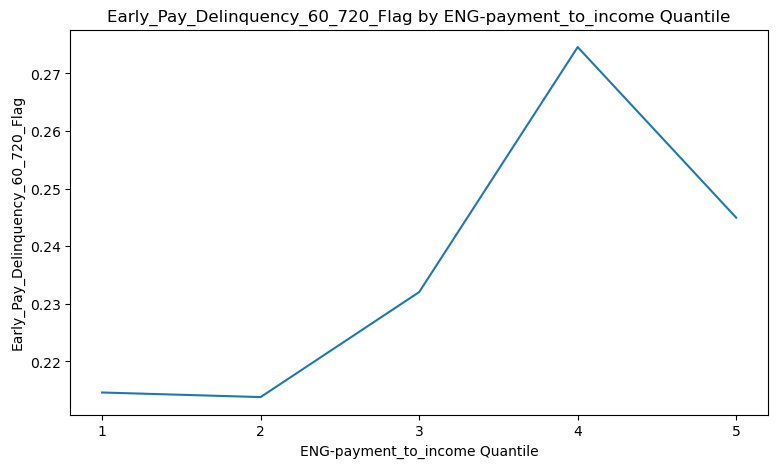

In [31]:
# get quantile
str_col = 'ENG-payment_to_income'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### List of columns in model

In [32]:
# structure
list_cols_structure = [
    'fltgrossmonthly__income_sum', # income
    'miles_odometer__app',
    'ENG-franchise',
    #'ENG-has_codebtor',
    'ENG-vehicle_age', # vehicle age
    'ENG-payment_to_income', # payment to income
    'ENG-loan_to_value', # loan to value
    'ENG-bk', # bk
    'dti__app', # debt to income
]

In [33]:
# pmt history
list_cols_pmt_hx = [
    # pmt hx
    'flt_mean_months_to_first_bad__tu_pmthx', # avg proportion of months to first bad pmt (low is bad)
    # open
    'flt_payment_open__tu_pmthx',
    'int_n_months_open__tu_pmthx',
    'flt_wtd_avg_open__tu_pmthx', # weighted avg of most recent open (low is bad)
    'flt_avg_open__tu_pmthx', # avg of most recent open (low is bad)
    'int_30dpd_open__tu_pmthx', # n times 30 dpd of most recent open
    'int_60dpd_open__tu_pmthx', # n times 60 dpd of most recent open
    'int_90dpd_open__tu_pmthx', # n times 90 dpd of most recent open
    # closed
    'int_n_months_closed__tu_pmthx',
    'flt_wtd_avg_closed__tu_pmthx',
    'flt_avg_closed__tu_pmthx',
    'int_30dpd_closed__tu_pmthx',
    'int_60dpd_closed__tu_pmthx',
    'int_90dpd_closed__tu_pmthx',
    # handpicked
    're01s__tu', # top feature in PD
    'g990s__tu', # highest shap in PD
    'g106s__tu', # in all 4 scorecards
    'addrinputtimenewest__ln', # Time on file (in months) since the subject was most recently reported at the input address
    'g980s__tu',
    'bkc321__tu',
    'balmag01__tu',
    'at35a__tu',
    'linka029__tu', # checking account inquiries
    'au25s__tu',
    'au27s__tu',
    'at28b__tu',
    'addrlastmovetaxratiodiff__ln',
    'g232s__tu',
    'g306s__tu',
    'au21s__tu',
    'addrinputproblems__ln',
    'linka006__tu',
    'inquiryshortterm12month__ln',
    'g234s__tu',
    'cv15__tu',
    'at21s__tu',
    'inquirybanking12month__ln',
    'g242s__tu',
    'paymnt11__tu',
    'inquirytelcom12month__ln',
    's073b__tu',
    's064b__tu',
    'linka017__tu',
    'g213a__tu',
    'derogseverityindex__ln',
]

In [34]:
# combine lists
#list_cols_model = list_cols_structure + list_cols_pmt_hx + list_cols_tu
list_cols_model = list_cols_structure + list_cols_pmt_hx
print(f'There are {len(list_cols_model)} starting features')

There are 53 starting features


In [35]:
# show the duplicates
ser_freq = pd.Series(list_cols_model).value_counts()
ser_freq = ser_freq[ser_freq > 1]
dict_freq = dict(ser_freq)
print('Duplicate Columns:')
a = 1
for key, val in dict_freq.items():
    print(f'{a}: {key}: {val}')
    a += 1
print('')
# rm dups
list_cols_model = list(dict.fromkeys(list_cols_model))
# make copy
list_cols_model_original = list_cols_model.copy()
# show
print('All Unique Columns:')
for a, col in enumerate(list_cols_model):
    try:
        str_description = dict_map_descriptions[col]
    except KeyError:
        str_description = 'NaN'
    print(f'{a+1}: {col} - {str_description}')

Duplicate Columns:

All Unique Columns:
1: fltgrossmonthly__income_sum - NaN
2: miles_odometer__app - NaN
3: ENG-franchise - NaN
4: ENG-vehicle_age - NaN
5: ENG-payment_to_income - NaN
6: ENG-loan_to_value - NaN
7: ENG-bk - NaN
8: dti__app - NaN
9: flt_mean_months_to_first_bad__tu_pmthx - NaN
10: flt_payment_open__tu_pmthx - NaN
11: int_n_months_open__tu_pmthx - NaN
12: flt_wtd_avg_open__tu_pmthx - NaN
13: flt_avg_open__tu_pmthx - NaN
14: int_30dpd_open__tu_pmthx - NaN
15: int_60dpd_open__tu_pmthx - NaN
16: int_90dpd_open__tu_pmthx - NaN
17: int_n_months_closed__tu_pmthx - NaN
18: flt_wtd_avg_closed__tu_pmthx - NaN
19: flt_avg_closed__tu_pmthx - NaN
20: int_30dpd_closed__tu_pmthx - NaN
21: int_60dpd_closed__tu_pmthx - NaN
22: int_90dpd_closed__tu_pmthx - NaN
23: re01s__tu - Number of revolving trades
24: g990s__tu - Number of deduped inquiries in past 12 months
25: g106s__tu - Months on file
26: addrinputtimenewest__ln - Time on file (in months) since the subject was most recently repo

#### Identify all nan in training

In [36]:
list_cols_drop = []
for col in tqdm(df.columns):
    flt_prop_nan = df[df['data_set'] == 'train'][col].isnull().mean()
    if flt_prop_nan == 1:
        list_cols_drop.append(col)
    else:
        pass
    
list_cols_model_original = [col for col in list_cols_model if col not in list_cols_drop]
list_cols_drop

100%|██████████| 104/104 [00:00<00:00, 155.41it/s]


['p02g__tu',
 'p02b__tu',
 'scap01__tu',
 'utlmag01__tu',
 'aepmag01__tu',
 'p02h__tu',
 'ctc23__tu',
 'p02d__tu',
 'sc29s__tu',
 'lrev325__tu',
 'pdmag01__tu',
 'sc21s__tu',
 'ctc21__tu',
 'ctm21__tu',
 'sl99b__tu']

#### Get relationship with target in training data

In [37]:
int_n_quantiles = 5
df_tmp = get_suggested_constraints(
    df=df[df['data_set'] == 'train'].copy(),
    list_cols_model=list_cols_model_original,
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
)
# map data dictionary
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions)
# show
df_tmp

100%|██████████| 53/53 [00:00<00:00, 68.14it/s]


,feature,intercept,slope,constraint,imputation,description
0,fltgrossmonthly__income_sum,0.310323,-0.018770,-1,min,NaN
1,miles_odometer__app,0.190749,0.021104,1,max,NaN
2,ENG-franchise,0.261851,-0.000011,-1,min,NaN
3,ENG-vehicle_age,0.235999,0.007960,1,max,NaN
4,ENG-payment_to_income,0.199520,0.012152,1,max,NaN
5,ENG-loan_to_value,0.188486,0.021845,1,max,NaN
6,ENG-bk,0.282052,-0.000019,-1,min,NaN
7,dti__app,0.213282,0.013586,1,max,NaN
8,flt_mean_months_to_first_bad__tu_pmthx,0.288538,-0.015739,-1,min,NaN
9,flt_payment_open__tu_pmthx,0.234798,0.000067,1,max,NaN


#### Create monotone constraints dictionary for later

In [38]:
dict_monotone_constraints = dict(zip(df_tmp['feature'], df_tmp['constraint']))

# manually alter
#dict_monotone_constraints['addrinputtimenewest__ln'] = -1

# save
str_filename = 'dict_monotone_constraints.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(dict_monotone_constraints, open(str_local_path, 'wb'))

# show
dict_monotone_constraints

{'fltgrossmonthly__income_sum': -1,
 'miles_odometer__app': 1,
 'ENG-franchise': -1,
 'ENG-vehicle_age': 1,
 'ENG-payment_to_income': 1,
 'ENG-loan_to_value': 1,
 'ENG-bk': -1,
 'dti__app': 1,
 'flt_mean_months_to_first_bad__tu_pmthx': -1,
 'flt_payment_open__tu_pmthx': 1,
 'int_n_months_open__tu_pmthx': -1,
 'flt_wtd_avg_open__tu_pmthx': -1,
 'flt_avg_open__tu_pmthx': -1,
 'int_30dpd_open__tu_pmthx': 1,
 'int_60dpd_open__tu_pmthx': 1,
 'int_90dpd_open__tu_pmthx': 1,
 'int_n_months_closed__tu_pmthx': -1,
 'flt_wtd_avg_closed__tu_pmthx': -1,
 'flt_avg_closed__tu_pmthx': -1,
 'int_30dpd_closed__tu_pmthx': -1,
 'int_60dpd_closed__tu_pmthx': -1,
 'int_90dpd_closed__tu_pmthx': 1,
 're01s__tu': -1,
 'g990s__tu': 1,
 'g106s__tu': -1,
 'addrinputtimenewest__ln': 1,
 'g980s__tu': 1,
 'bkc321__tu': -1,
 'balmag01__tu': 1,
 'at35a__tu': -1,
 'linka029__tu': 1,
 'au25s__tu': -1,
 'au27s__tu': -1,
 'at28b__tu': -1,
 'addrlastmovetaxratiodiff__ln': 1,
 'g232s__tu': 1,
 'g306s__tu': -1,
 'au21s__tu':

#### Create dictionary for imputation type

In [39]:
dict_impute_type = dict(zip(df_tmp['feature'], df_tmp['imputation']))
# create an imputation dictionary
dict_impute = {}
df_train = df[df['data_set'] == 'train'].copy()
for key, val in tqdm(dict_impute_type.items()):
    # logic
    if val == 'min':
        flt_val = df_train[key].min()
    else:
        flt_val = df_train[key].max()
    # assign
    dict_impute[key] = flt_val
    
# save
str_filename = 'dict_impute.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(dict_impute, open(str_local_path, 'wb'))

# save memory
del df_train
# show
dict_impute

100%|██████████| 53/53 [00:00<00:00, 11631.95it/s]


{'fltgrossmonthly__income_sum': 0.0,
 'miles_odometer__app': 150780.0,
 'ENG-franchise': 0,
 'ENG-vehicle_age': 11,
 'ENG-payment_to_income': 402.0,
 'ENG-loan_to_value': 1.672390004599111,
 'ENG-bk': 0,
 'dti__app': 4.761775923330182,
 'flt_mean_months_to_first_bad__tu_pmthx': 0.0,
 'flt_payment_open__tu_pmthx': 1398.0,
 'int_n_months_open__tu_pmthx': 0.0,
 'flt_wtd_avg_open__tu_pmthx': 0.0,
 'flt_avg_open__tu_pmthx': 0.0,
 'int_30dpd_open__tu_pmthx': 47.0,
 'int_60dpd_open__tu_pmthx': 42.0,
 'int_90dpd_open__tu_pmthx': 72.0,
 'int_n_months_closed__tu_pmthx': 0.0,
 'flt_wtd_avg_closed__tu_pmthx': 0.0,
 'flt_avg_closed__tu_pmthx': 0.0,
 'int_30dpd_closed__tu_pmthx': 0.0,
 'int_60dpd_closed__tu_pmthx': 0.0,
 'int_90dpd_closed__tu_pmthx': 47.0,
 're01s__tu': 0.0,
 'g990s__tu': 39.0,
 'g106s__tu': 0.0,
 'addrinputtimenewest__ln': 271.0,
 'g980s__tu': 24.0,
 'bkc321__tu': 0.0,
 'balmag01__tu': 600.0,
 'at35a__tu': 0.0,
 'linka029__tu': 99.0,
 'au25s__tu': 0.0,
 'au27s__tu': 0.0,
 'at28b__t

In [40]:
# impute
for key, val in tqdm(dict_impute.items()):
    # replace any infs with nan
    df[key] = df[key].replace(np.inf, np.nan)
    # fillna
    df[key] = df[key].fillna(val)
# show
df

100%|██████████| 53/53 [00:00<00:00, 1091.46it/s]


,data_set,days_on_books,applicationdate__app,accountid,bitdebtor__app,Early_Pay_Delinquency_60_720_Flag,fltgrossmonthly__income_sum,miles_odometer__app,flt_payment_open__tu_pmthx,ENG-franchise,...,trv01__tu,aggs911__tu,au202s__tu,au34s__tu,bi21s__tu,bkc322__tu,ctc21__tu,ctm21__tu,in57s__tu,sl99b__tu
175,train,1215,2021-07-22 17:37:28.093,5716209,1,0,7157.0,28796.0,1398.0,1,...,1.0,100.0,NaN,NaN,89.0,1.0,NaN,NaN,NaN,NaN
154,train,1215,2021-07-07 12:49:20.480,5702150,1,0,7662.0,41384.0,1398.0,1,...,999.0,41.0,1.0,NaN,154.0,20.0,NaN,NaN,NaN,NaN
18,train,1218,2021-07-07 12:17:51.430,5702106,1,0,8286.1,22951.0,1398.0,1,...,NaN,NaN,0.0,NaN,189.0,NaN,NaN,NaN,NaN,NaN
207,train,1215,2021-07-21 13:45:49.677,5714824,0,0,4415.0,36659.0,501.0,1,...,NaN,NaN,1.0,92.0,25.0,NaN,NaN,NaN,0.0,NaN
206,train,1215,2021-07-21 13:45:49.677,5714824,1,0,3461.0,36659.0,364.0,1,...,999.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42089,holdout,721,2022-11-28 12:25:18.957,6464887,1,0,4836.0,41431.0,1398.0,1,...,3.0,95.0,2.0,NaN,NaN,160.0,NaN,NaN,NaN,NaN
42197,holdout,720,2022-11-28 11:17:53.530,6464638,1,0,3005.0,98954.0,1398.0,0,...,999.0,68.0,0.0,NaN,51.0,303.0,NaN,NaN,0.0,NaN
41923,holdout,725,2022-11-28 10:17:32.573,6464416,1,0,4247.0,83840.0,713.0,0,...,1.0,NaN,2.0,37.0,NaN,NaN,NaN,NaN,0.0,NaN
42062,holdout,722,2022-11-28 15:09:59.617,6465473,1,0,4160.0,70856.0,1398.0,1,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Get proportion missing by column by data set

In [41]:
list_dict_row = []
for col in tqdm(list_cols_model_original):
    dict_row = {'feature': col}
    for str_df in ['train','test','holdout']:
        flt_propna = df[df['data_set'] == str_df][col].isnull().mean()
        # assign
        dict_row[str_df] = flt_propna
    # append
    list_dict_row.append(dict_row)
# make df
df_tmp = pd.DataFrame(list_dict_row)
# get max
df_tmp['max'] = df_tmp[['train','test','holdout']].max(axis=1)
# map
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions)
# show
df_tmp.sort_values(by='max', ascending=False, inplace=True)
df_tmp

100%|██████████| 53/53 [00:01<00:00, 40.44it/s]


,feature,train,test,holdout,max,description
0,fltgrossmonthly__income_sum,0.0,0.0,0.0,0.0,NaN
1,miles_odometer__app,0.0,0.0,0.0,0.0,NaN
2,ENG-franchise,0.0,0.0,0.0,0.0,NaN
3,ENG-vehicle_age,0.0,0.0,0.0,0.0,NaN
4,ENG-payment_to_income,0.0,0.0,0.0,0.0,NaN
5,ENG-loan_to_value,0.0,0.0,0.0,0.0,NaN
6,ENG-bk,0.0,0.0,0.0,0.0,NaN
7,dti__app,0.0,0.0,0.0,0.0,NaN
8,flt_mean_months_to_first_bad__tu_pmthx,0.0,0.0,0.0,0.0,NaN
9,flt_payment_open__tu_pmthx,0.0,0.0,0.0,0.0,NaN


#### Show the features that are 100% NaN

In [42]:
df_all_nan = df_tmp[df_tmp['max'] == 1].copy()
# get list
list_str_all_nan = list(df_all_nan['feature'])
print(f'There are {len(list_str_all_nan)} features 100% missing')
# show
df_all_nan

There are 0 features 100% missing


,feature,train,test,holdout,max,description


#### Show proportion missing

In [43]:
ser_isnull = df[list_cols_model_original].isnull().mean()
ser_isnull[ser_isnull > 0]

Series([], dtype: float64)

#### Get info from inform set

In [44]:
# get the inform data set
df_inform = df[df['data_set'] == 'inform'].copy()
# get target value
flt_target_value = df_inform[str_target].mean()
print(f'Target Value: {flt_target_value:0.4f}')

Target Value: 0.2738


#### Get train to match the inform set

In [45]:
%%time

# get the training data
df_train = df[df['data_set'] == 'train'].copy()
# get current target mean
flt_current_value = df_train[str_target].mean()
print(f'Target Value Before Sampling: {flt_current_value:0.4f}')
# init
cls_sample = OverSampling(
    df=df_train,
    str_target=str_target,
    flt_target_value=flt_target_value,
    flt_current_value=flt_current_value,
)
# sample
df_train = cls_sample.sample()
# get current target mean
flt_current_value = df_train[str_target].mean()
print(f'Target Value After Sampling: {flt_current_value:0.4f}')
print()
# show
df_train

Target Value Before Sampling: 0.2540
Target Value After Sampling: 0.2739

CPU times: user 36.1 ms, sys: 16.1 ms, total: 52.2 ms
Wall time: 51.2 ms


,data_set,days_on_books,applicationdate__app,accountid,bitdebtor__app,Early_Pay_Delinquency_60_720_Flag,fltgrossmonthly__income_sum,miles_odometer__app,flt_payment_open__tu_pmthx,ENG-franchise,...,trv01__tu,aggs911__tu,au202s__tu,au34s__tu,bi21s__tu,bkc322__tu,ctc21__tu,ctm21__tu,in57s__tu,sl99b__tu
11907,train,1013,2022-02-09 11:52:20.563,5923735,0,0,3094.0,47590.0,235.0,0,...,1.0,112.0,0.0,89.0,NaN,0.0,NaN,NaN,21.0,NaN
9073,train,1064,2021-12-22 14:48:20.497,5876750,0,0,6536.0,14974.0,490.0,1,...,15.0,NaN,0.0,38.0,NaN,NaN,NaN,NaN,692.0,NaN
102,train,1211,2021-07-12 09:45:30.283,5706177,1,0,5417.0,23860.0,1398.0,1,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14833,train,978,2022-03-10 11:43:16.397,5965992,0,0,3467.0,79459.0,1398.0,1,...,1.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2705,train,1148,2021-09-16 14:13:33.627,5765640,0,1,5631.0,6.0,526.0,1,...,NaN,NaN,0.0,94.0,NaN,NaN,NaN,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7505,train,1092,2021-11-10 19:15:07.067,5824028,1,1,8286.1,85454.0,1398.0,1,...,1.0,118.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
6332,train,1100,2021-11-13 16:35:24.383,5828024,0,0,2917.0,78664.0,422.0,1,...,1.0,120.0,1.0,89.0,NaN,0.0,NaN,NaN,834.0,NaN
890,train,1190,2021-07-15 20:57:19.440,5709926,1,0,4853.0,95516.0,240.0,1,...,999.0,NaN,2.0,92.0,NaN,NaN,NaN,NaN,240.0,NaN
3295,train,1142,2021-09-11 09:32:13.130,5760680,1,1,2721.0,70122.0,1398.0,1,...,1.0,114.0,NaN,NaN,6.0,0.0,NaN,NaN,NaN,NaN


#### Get test to match the inform set


In [46]:
%%time

df_test = df[df['data_set'] == 'test'].copy()
# get current target mean
flt_current_value = df_test[str_target].mean()
print(f'Target Value Before Sampling: {flt_current_value:0.4f}')
# init
cls_sample = OverSampling(
    df=df_test,
    str_target=str_target,
    flt_target_value=flt_target_value,
    flt_current_value=flt_current_value,
)
# sample
df_test = cls_sample.sample()
# get current target mean
flt_current_value = df_test[str_target].mean()
print(f'Target Value After Sampling: {flt_current_value:0.4f}')
print()
# show
df_test

Target Value Before Sampling: 0.2998
Target Value After Sampling: 0.2738

CPU times: user 34.3 ms, sys: 140 μs, total: 34.4 ms
Wall time: 33.6 ms


,data_set,days_on_books,applicationdate__app,accountid,bitdebtor__app,Early_Pay_Delinquency_60_720_Flag,fltgrossmonthly__income_sum,miles_odometer__app,flt_payment_open__tu_pmthx,ENG-franchise,...,trv01__tu,aggs911__tu,au202s__tu,au34s__tu,bi21s__tu,bkc322__tu,ctc21__tu,ctm21__tu,in57s__tu,sl99b__tu
17439,test,952,2022-04-05 12:27:18.240,6012614,1,0,6703.0,49787.0,376.0,1,...,1.0,112.0,1.0,94.0,82.0,167.0,NaN,NaN,82.0,NaN
26952,test,859,2022-07-12 11:41:43.967,6162319,1,0,3474.0,99172.0,580.0,0,...,NaN,NaN,2.0,68.0,59.0,NaN,NaN,NaN,0.0,NaN
24565,test,883,2022-06-14 16:45:54.453,6122326,1,1,3699.0,91575.0,1398.0,0,...,16.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15775,test,970,2022-02-28 19:14:38.147,5951280,1,0,4652.0,59697.0,1398.0,1,...,1.0,NaN,1.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
17044,test,957,2022-04-01 16:19:26.307,5998301,1,0,7107.0,98498.0,1398.0,0,...,1.0,108.0,1.0,NaN,187.0,2.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26124,test,868,2022-07-05 15:51:07.350,6152457,0,1,2947.0,84659.0,1398.0,1,...,NaN,NaN,1.0,NaN,63.0,NaN,NaN,NaN,0.0,NaN
23870,test,890,2022-06-16 17:12:27.527,6125573,1,0,3339.0,86565.0,1398.0,0,...,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24590,test,883,2022-06-20 08:19:26.697,6129815,1,0,7176.0,76670.0,1398.0,0,...,1.0,120.0,1.0,NaN,186.0,0.0,NaN,NaN,0.0,NaN
18312,test,945,2022-04-18 08:35:26.957,6029481,1,0,4626.0,37387.0,390.0,1,...,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN


#### List of columns to start

In [47]:
print(f'Starting with {len(list_cols_model_original)} features:')
for a, col in enumerate(list_cols_model_original):
    print(f'{a+1}: {col}')

Starting with 53 features:
1: fltgrossmonthly__income_sum
2: miles_odometer__app
3: ENG-franchise
4: ENG-vehicle_age
5: ENG-payment_to_income
6: ENG-loan_to_value
7: ENG-bk
8: dti__app
9: flt_mean_months_to_first_bad__tu_pmthx
10: flt_payment_open__tu_pmthx
11: int_n_months_open__tu_pmthx
12: flt_wtd_avg_open__tu_pmthx
13: flt_avg_open__tu_pmthx
14: int_30dpd_open__tu_pmthx
15: int_60dpd_open__tu_pmthx
16: int_90dpd_open__tu_pmthx
17: int_n_months_closed__tu_pmthx
18: flt_wtd_avg_closed__tu_pmthx
19: flt_avg_closed__tu_pmthx
20: int_30dpd_closed__tu_pmthx
21: int_60dpd_closed__tu_pmthx
22: int_90dpd_closed__tu_pmthx
23: re01s__tu
24: g990s__tu
25: g106s__tu
26: addrinputtimenewest__ln
27: g980s__tu
28: bkc321__tu
29: balmag01__tu
30: at35a__tu
31: linka029__tu
32: au25s__tu
33: au27s__tu
34: at28b__tu
35: addrlastmovetaxratiodiff__ln
36: g232s__tu
37: g306s__tu
38: au21s__tu
39: addrinputproblems__ln
40: linka006__tu
41: inquiryshortterm12month__ln
42: g234s__tu
43: cv15__tu
44: at21s_

#### Split into X and y

In [48]:
# train
X_train = df_train[list_cols_model_original]
y_train = df_train[str_target]
# save memory
del df_train

In [49]:
# test
X_test = df_test[list_cols_model_original]
y_test = df_test[str_target]
# save memory
del df_test

In [50]:
# holdout
X_holdout = df[df['data_set'] == 'holdout'][list_cols_model_original].copy()
y_holdout = df[df['data_set'] == 'holdout'][str_target]
# save memory
del df

#### Monotone constraints

In [51]:
dict_monotone_constraints

{'fltgrossmonthly__income_sum': -1,
 'miles_odometer__app': 1,
 'ENG-franchise': -1,
 'ENG-vehicle_age': 1,
 'ENG-payment_to_income': 1,
 'ENG-loan_to_value': 1,
 'ENG-bk': -1,
 'dti__app': 1,
 'flt_mean_months_to_first_bad__tu_pmthx': -1,
 'flt_payment_open__tu_pmthx': 1,
 'int_n_months_open__tu_pmthx': -1,
 'flt_wtd_avg_open__tu_pmthx': -1,
 'flt_avg_open__tu_pmthx': -1,
 'int_30dpd_open__tu_pmthx': 1,
 'int_60dpd_open__tu_pmthx': 1,
 'int_90dpd_open__tu_pmthx': 1,
 'int_n_months_closed__tu_pmthx': -1,
 'flt_wtd_avg_closed__tu_pmthx': -1,
 'flt_avg_closed__tu_pmthx': -1,
 'int_30dpd_closed__tu_pmthx': -1,
 'int_60dpd_closed__tu_pmthx': -1,
 'int_90dpd_closed__tu_pmthx': 1,
 're01s__tu': -1,
 'g990s__tu': 1,
 'g106s__tu': -1,
 'addrinputtimenewest__ln': 1,
 'g980s__tu': 1,
 'bkc321__tu': -1,
 'balmag01__tu': 1,
 'at35a__tu': -1,
 'linka029__tu': 1,
 'au25s__tu': -1,
 'au27s__tu': -1,
 'at28b__tu': -1,
 'addrlastmovetaxratiodiff__ln': 1,
 'g232s__tu': 1,
 'g306s__tu': -1,
 'au21s__tu':

#### XGBoost - Feature Selection

In [52]:
%%time

list_cols_model = list_cols_model_original.copy()
X_train_tmp = X_train.copy()
X_test_tmp = X_test.copy()

list_dict_row = []
counter = 0
while True:
    # tmp
    X_train_tmp = X_train_tmp[list_cols_model].copy()
    X_test_tmp = X_test_tmp[list_cols_model].copy()
    
    # ensure features are in list_cols_model
    dict_monotone_constraints_tmp = {key: val for key, val in dict_monotone_constraints.items() if key in list_cols_model}
    
    # init model
    cls_model_inference = xbm.XGBClassifier(
        n_estimators=int_n_iterations,
        early_stopping_rounds=int_n_early_stopping,
        eval_metric='auc',
        #monotone_constraints=dict_monotone_constraints_tmp,
        max_depth=int_max_depth,
    )
    # fit
    cls_model_inference.fit(
        X=X_train_tmp,
        y=y_train,
        eval_set=[(X_test_tmp, y_test)],
        verbose=False,
    )
    
    # get predictions
    y_hat_train = cls_model_inference.predict_proba(X_train_tmp)[:,1]
    y_hat_valid = cls_model_inference.predict_proba(X_test_tmp)[:,1]
    y_hat_holdout = cls_model_inference.predict_proba(X_holdout[list_cols_model])[:,1]
    
    # get the training eval metric
    flt_eval_metric_train = skm.roc_auc_score(y_true=y_train, y_score=y_hat_train)
    # get valid eval metric
    flt_eval_metric_valid = skm.roc_auc_score(y_true=y_test, y_score=y_hat_valid)
    # get holdout eval metric
    flt_eval_metric_holdout = skm.roc_auc_score(y_true=y_holdout, y_score=y_hat_holdout)
    
    # make a row
    dict_row = {
        'iteration': counter,
        'flt_eval_metric_train': flt_eval_metric_train,
        'flt_eval_metric_valid': flt_eval_metric_valid,
        'flt_eval_metric_holdout': flt_eval_metric_holdout,
        'list_cols_model': list_cols_model,
        'n_feats': len(list_cols_model),
        'cls_model_inference': cls_model_inference,
    }
    # append
    list_dict_row.append(dict_row)
    
    # get feature importance
    df_feat_imp = get_xgboost_feat_importance(
        cls_model_inference=cls_model_inference,
    )
    
    # remove the bottom n
    int_n_remove = 1
    list_cols_keep = list(df_feat_imp['feature'])[:-int_n_remove]
    
    # break if there are no features
    int_n_keep = 10
    if len(list_cols_keep) < int_n_keep:
        break
        
    # get the features we will not keep
    list_cols_drop = [col for col in list_cols_model if col not in list_cols_keep]
    # get the number of features we will drop
    int_n_dropped = len(list_cols_drop)
    # if there are no features to drop
    if int_n_dropped == 0:
        break
    else:
        list_cols_model = list_cols_keep
        counter += 1
# make df
df_tmp_xg = pd.DataFrame(list_dict_row)
# show
#df_tmp_xg

CPU times: user 26.6 s, sys: 330 ms, total: 26.9 s
Wall time: 3.4 s


#### Catboost - Feature selection

In [53]:
%%time

list_cols_model = list_cols_model_original.copy()
X_train_tmp = X_train.copy()
X_test_tmp = X_test.copy()

list_dict_row = []
counter = 0
while True:
    # tmp
    X_train_tmp = X_train_tmp[list_cols_model].copy()
    X_test_tmp = X_test_tmp[list_cols_model].copy()
    
    # get the non numeric feats
    list_cols_non_numeric = []
    for col in list_cols_model:
        if X_train_tmp[col].dtype not in ['int64','float64']:
            list_cols_non_numeric.append(col)

    # pool data
    pool_train = cb.Pool(
        X_train_tmp, 
        y_train, 
        cat_features=list_cols_non_numeric,
    )
    # pool
    pool_valid = cb.Pool(
        X_test_tmp, 
        y_test, 
        cat_features=list_cols_non_numeric,
    )
    
    # ensure features are in list_cols_model
    dict_monotone_constraints_tmp = {key: val for key, val in dict_monotone_constraints_tmp.items() if key in list_cols_model}
    # init class
    cls_model_inference = cb.CatBoostClassifier(
        task_type='CPU',
        nan_mode='Min',
        random_state=42,
        eval_metric='AUC',
        iterations=int_n_iterations,
        learning_rate=None,
        class_weights=None,
        #monotone_constraints=dict_monotone_constraints,
        depth=int_max_depth,
    )
    # fit
    cls_model_inference.fit(
        pool_train,
        eval_set=[pool_valid],
        verbose=False,
        use_best_model=True,
        early_stopping_rounds=int_n_early_stopping, 
    )
    # get predictions
    y_hat_train = cls_model_inference.predict_proba(pool_train)[:,1]
    y_hat_valid = cls_model_inference.predict_proba(pool_valid)[:,1]
    y_hat_holdout = cls_model_inference.predict_proba(X_holdout[list_cols_model])[:,1]
    
    # get the training eval metric
    flt_eval_metric_train = skm.roc_auc_score(y_true=y_train, y_score=y_hat_train)
    # get valid eval metric
    flt_eval_metric_valid = skm.roc_auc_score(y_true=y_test, y_score=y_hat_valid)
    # get holdout eval metric
    flt_eval_metric_holdout = skm.roc_auc_score(y_true=y_holdout, y_score=y_hat_holdout)
    
    # make a row
    dict_row = {
        'iteration': counter,
        'flt_eval_metric_train': flt_eval_metric_train,
        'flt_eval_metric_valid': flt_eval_metric_valid,
        'flt_eval_metric_holdout': flt_eval_metric_holdout,
        'list_cols_model': list_cols_model,
        'n_feats': len(list_cols_model),
        'cls_model_inference': cls_model_inference,
    }
    # append
    list_dict_row.append(dict_row)

    # get importance
    df_feat_imp = get_catboost_feat_importance(
        cls_model_inference=cls_model_inference,
        pool_eval=pool_valid,
    )
    
    # remove the bottom n
    int_n_remove = 1
    list_cols_keep = list(df_feat_imp['feature'])[:-int_n_remove]
    
    # break if there are no features
    int_n_keep = 10
    if len(list_cols_keep) < int_n_keep:
        break
    
    # get the features we will not keep
    list_cols_drop = [col for col in list_cols_model if col not in list_cols_keep]
    # get the number of features we will drop
    int_n_dropped = len(list_cols_drop)
    # if there are no features to drop
    if int_n_dropped == 0:
        break
    else:
        list_cols_model = list_cols_keep
        counter += 1
# make df
df_tmp_cb = pd.DataFrame(list_dict_row)
# show
#df_tmp_cb

CPU times: user 49.3 s, sys: 4.52 s, total: 53.9 s
Wall time: 10.2 s


#### Logistic regression - Feature selection

In [54]:
# scale
list_cols_model = list_cols_model_original.copy()
# init
cls_scaler = StandardScaler()

# train
X_train_tmp = cls_scaler.fit_transform(X_train[list_cols_model])

# save
str_filename = 'cls_scaler.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(cls_scaler, open(str_local_path, 'wb'))

In [55]:
# train
X_train_tmp = pd.DataFrame(X_train_tmp, columns=list_cols_model)
ser_isnull = X_train_tmp.isnull().mean()
ser_isnull[ser_isnull > 0]

Series([], dtype: float64)

In [56]:
# test
X_test_tmp = cls_scaler.transform(X_test[list_cols_model])
X_test_tmp = pd.DataFrame(X_test_tmp, columns=list_cols_model)
ser_isnull = X_test_tmp.isnull().mean()
ser_isnull[ser_isnull > 0]

Series([], dtype: float64)

In [57]:
# holdout
X_holdout_tmp = cls_scaler.transform(X_holdout[list_cols_model])
X_holdout_tmp = pd.DataFrame(X_holdout_tmp, columns=list_cols_model)
ser_isnull = X_holdout_tmp.isnull().mean()
ser_isnull[ser_isnull > 0]

Series([], dtype: float64)

In [58]:
%%time

list_dict_row = []
counter = 0
while True:
    # tmp
    X_train_tmp_tmp = X_train_tmp[list_cols_model].copy()
    X_test_tmp_tmp = X_test_tmp[list_cols_model].copy()
    X_holdout_tmp_tmp = X_holdout_tmp[list_cols_model].copy()
        
    # init
    cls_model_inference = LogisticRegression(
        penalty='l2',
        random_state=42,
        fit_intercept=True,
    )
    # fit
    cls_model_inference.fit(
        X_train_tmp_tmp,
        y_train,
    )
    
    # get predictions
    y_hat_train = cls_model_inference.predict_proba(X_train_tmp_tmp)[:,1]
    y_hat_valid = cls_model_inference.predict_proba(X_test_tmp_tmp)[:,1]
    y_hat_holdout = cls_model_inference.predict_proba(X_holdout_tmp_tmp)[:,1]
    
    # get the training eval metric
    flt_eval_metric_train = skm.roc_auc_score(y_true=y_train, y_score=y_hat_train)
    # get valid eval metric
    flt_eval_metric_valid = skm.roc_auc_score(y_true=y_test, y_score=y_hat_valid)
    # get holdout eval metric
    flt_eval_metric_holdout = skm.roc_auc_score(y_true=y_holdout, y_score=y_hat_holdout)
    
    # make a row
    dict_row = {
        'iteration': counter,
        'flt_eval_metric_train': flt_eval_metric_train,
        'flt_eval_metric_valid': flt_eval_metric_valid,
        'flt_eval_metric_holdout': flt_eval_metric_holdout,
        'list_cols_model': list_cols_model,
        'n_feats': len(list_cols_model),
        'cls_model_inference': cls_model_inference,
    }
    # append
    list_dict_row.append(dict_row)
    
    # get feature importance in valid/test set
    df_feat_imp = get_logistic_regression_feat_importance(
        df=X_test_tmp_tmp,
        cls_model_inference=cls_model_inference,
    )
    
    # remove the bottom n
    int_n_remove = 1
    list_cols_keep = list(df_feat_imp['feature'])[:-int_n_remove]
    
    # break if there are no features
    int_n_keep = 10
    if len(list_cols_keep) < int_n_keep:
        break
    
    # get the features we will not keep
    list_cols_drop = [col for col in list_cols_model if col not in list_cols_keep]
    # get the number of features we will drop
    int_n_dropped = len(list_cols_drop)
    # if there are no features to drop
    if int_n_dropped == 0:
        break
    else:
        list_cols_model = list_cols_keep
        counter += 1
# make df
df_tmp_lr = pd.DataFrame(list_dict_row)
# show
#df_tmp_lr

CPU times: user 19.6 s, sys: 280 ms, total: 19.9 s
Wall time: 4.99 s


#### Concatenate

In [59]:
df_tmp = pd.concat([df_tmp_xg, df_tmp_cb, df_tmp_lr])
# get scaled score
#df_tmp = get_scaled_score(df=df_tmp)
df_tmp.sort_values(by='flt_eval_metric_valid', ascending=False, inplace=True)
# show
df_tmp

,iteration,flt_eval_metric_train,flt_eval_metric_valid,flt_eval_metric_holdout,list_cols_model,n_feats,cls_model_inference
32,32,0.666450,0.653905,0.650868,"[dti__app, ENG-loan_to_value, derogseverityind...",21,<catboost.core.CatBoostClassifier object at 0x...
1,1,0.675456,0.653843,0.651712,"[g213a__tu, g106s__tu, dti__app, ENG-bk, int_n...",27,"XGBClassifier(base_score=None, booster=None, c..."
4,4,0.672492,0.653642,0.651833,"[g213a__tu, g106s__tu, dti__app, ENG-bk, derog...",24,"XGBClassifier(base_score=None, booster=None, c..."
0,0,0.674899,0.653563,0.652159,"[fltgrossmonthly__income_sum, miles_odometer__...",53,"XGBClassifier(base_score=None, booster=None, c..."
3,3,0.673301,0.653363,0.652073,"[g213a__tu, g106s__tu, dti__app, ENG-bk, int_n...",25,"XGBClassifier(base_score=None, booster=None, c..."
...,...,...,...,...,...,...,...
41,41,0.617419,0.616369,0.615577,"[linka029__tu, linka006__tu, dti__app, miles_o...",12,LogisticRegression(random_state=42)
40,40,0.617421,0.616267,0.615540,"[linka029__tu, linka006__tu, dti__app, miles_o...",13,LogisticRegression(random_state=42)
24,24,0.619102,0.607235,0.619151,"[dti__app, ENG-loan_to_value, bkc321__tu, dero...",29,<catboost.core.CatBoostClassifier object at 0x...
42,42,0.609629,0.600594,0.606978,"[linka029__tu, linka006__tu, dti__app, miles_o...",11,LogisticRegression(random_state=42)


#### Select model

In [60]:
# get best model
cls_model_inference = df_tmp['cls_model_inference'].iloc[0]

# get model type
str_model_type = str(type(cls_model_inference))

# logic
if str_model_type == "<class 'xgboost.sklearn.XGBClassifier'>":
    str_model_type = 'XGBoost'
elif str_model_type == "<class 'catboost.core.CatBoostClassifier'>":
    str_model_type = 'CatBoost'
else:
    str_model_type = 'LogisticRegression'
# print
print(f'Model Type: {str_model_type}')

# save
str_filename = 'cls_model_inference_ml.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(cls_model_inference, open(str_local_path, 'wb'))

# get features
list_cols_model_new = df_tmp['list_cols_model'].iloc[0]
print(f'There are {len(list_cols_model_new)} features in the model')

Model Type: CatBoost
There are 21 features in the model


In [61]:
# logic for predictions
if str_model_type == 'LogisticRegression':
    # get predictions
    list_predictions_train = list(cls_model_inference.predict_proba(X_train_tmp[list_cols_model_new])[:,1])
    list_predictions_test = list(cls_model_inference.predict_proba(X_test_tmp[list_cols_model_new])[:,1])
    list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout_tmp[list_cols_model_new])[:,1])
else:
    # get predictions
    list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_model_new])[:,1])
    list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_model_new])[:,1])
    list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_model_new])[:,1])

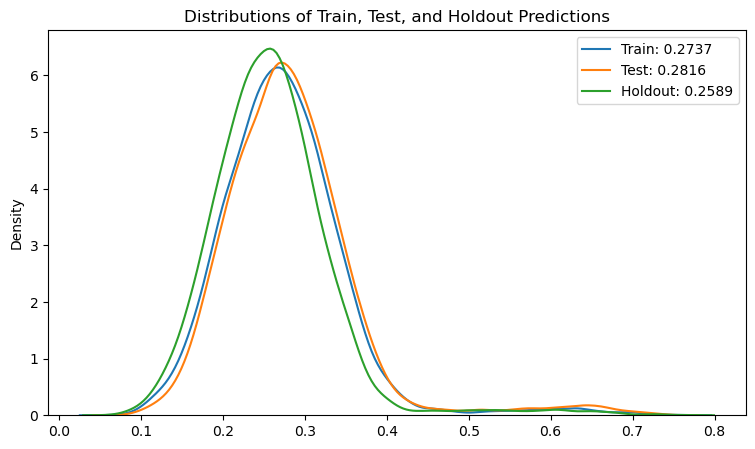

In [62]:
# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [63]:
# eval
flt_auc_train = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6664
AUC Test: 0.6539
AUC Holdout: 0.6509

Logloss Train: 0.5562
Logloss Test: 0.5580
Logloss Holdout: 0.5039

KS Train: 0.2329
KS Test: 0.2128
KS Holdout: 0.1702


In [64]:
# feature importance
if str_model_type == 'XGBoost':
    # XGBoost
    df_tmp = get_xgboost_feat_importance(
        cls_model_inference=cls_model_inference,
    )
elif str_model_type == 'CatBoost':
    # Catboost
    pool_valid = cb.Pool(
        X_test[list_cols_model_new].copy(), 
        y_test, 
    )
    df_tmp = get_catboost_feat_importance(
        cls_model_inference=cls_model_inference,
        pool_eval=pool_valid,
    )
else:
    # logistic regression
    df_tmp = get_logistic_regression_feat_importance(
        cls_model_inference=cls_model_inference,
        list_cols_model=list_cols_model_new,
        df=X_test_tmp,
    )
# map description
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions)
# make dictionary
dict_map_importance = dict(zip(df_tmp['feature'], df_tmp['importance']))
# show
df_tmp

,feature,importance,description
0,dti__app,0.009749,NaN
1,ENG-loan_to_value,0.002095,NaN
2,bkc321__tu,0.001736,Min Total Open-to-Buy for Bankcard accounts ov...
3,balmag01__tu,0.001674,Non-mortgage balance magnitude algorithm over ...
4,inquirybanking12month__ln,0.001187,Indicates subject has one or more LexisNexis b...
5,int_n_months_open__tu_pmthx,0.001092,NaN
6,inquiryshortterm12month__ln,0.001042,Indicates subject has one or more LexisNexis p...
7,derogseverityindex__ln,0.000934,Index indicating severity of derogatory record...
8,g106s__tu,0.000922,Months on file
9,cv15__tu,0.000739,Number of deduped auto inquiries


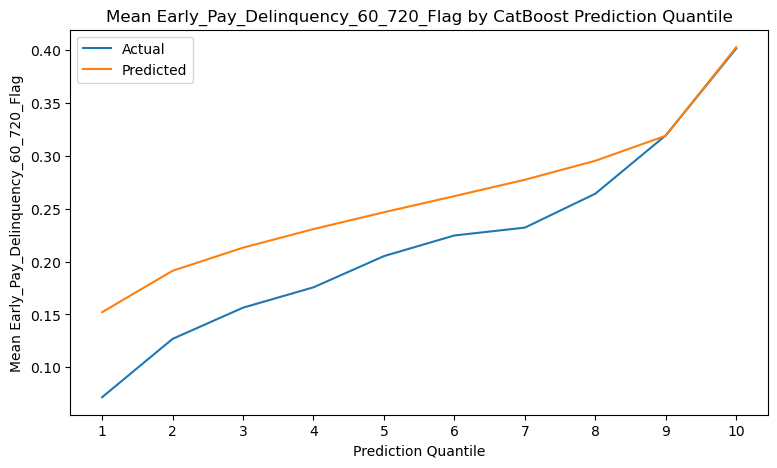

In [65]:
# mean actual by prediction quantile
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type=str_model_type,
)

In [66]:
# # directions of predictions
# int_n_quantiles = 10
# get_directions_of_predictions(
#     X=X_holdout.copy(),
#     list_predictions=list_predictions_holdout,
#     str_target=str_target,
#     list_actual=list(y_holdout),
#     list_cols=list_cols_model_new,
#     int_n_quantiles=int_n_quantiles,
# )

#### Linear model from ML model

In [67]:
# find multicollinear columns
df_tmp, list_cols_remove = remove_multicollinearity(
    X=X_train, 
    list_cols_model=list_cols_model_new, 
    dict_map_importance=dict_map_importance, 
    flt_threshold=flt_threshold,
)
print('Columns to Remove:')
for a, col in enumerate(list_cols_remove):
    print(f'{a+1} - {col}')
print()
# show
df_tmp

100%|██████████| 21/21 [00:00<00:00, 33.73it/s]

Columns to Remove:



,col1,col2,r,r_abs,col1_importance,col2_importance,high_correlation,remove_feature


In [68]:
# list cols
list_cols_tmp = [col for col in list_cols_model_new if col not in list_cols_remove]

# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
)
# fit
cls_model_inference.fit(
    X_train_tmp[list_cols_tmp].copy(),
    y_train,
)

# save
str_filename = 'cls_model_inference_ml_logistic.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(cls_model_inference, open(str_local_path, 'wb'))

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train_tmp[list_cols_tmp])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test_tmp[list_cols_tmp])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout_tmp[list_cols_tmp])[:,1])

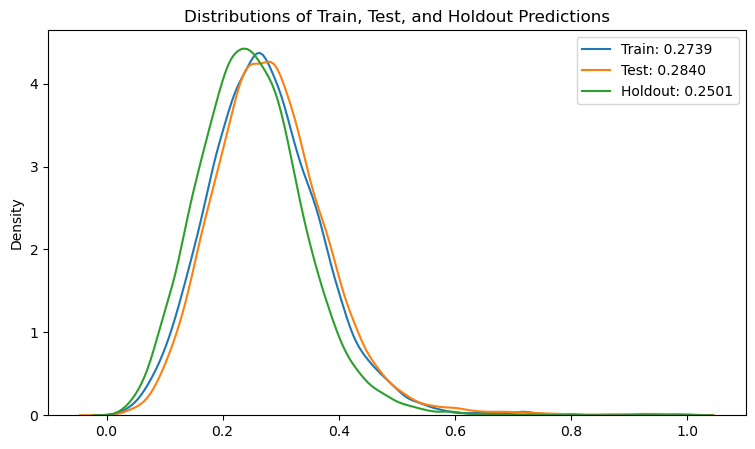

In [69]:
# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [70]:
# eval
flt_auc_train = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6405
AUC Test: 0.6369
AUC Holdout: 0.6407

Logloss Train: 0.5619
Logloss Test: 0.5631
Logloss Holdout: 0.5042

KS Train: 0.1958
KS Test: 0.1906
KS Holdout: 0.1949


In [71]:
# get feature importance
df_tmp = get_logistic_regression_feat_importance(
    cls_model_inference=cls_model_inference,
    list_cols_model=list_cols_tmp,
    df=X_test_tmp,
)
# map desceription
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions)
# show
df_tmp

,feature,importance,importance_abs,description
0,dti__app,0.020580,0.020580,NaN
19,ENG-bk,0.007353,0.007353,NaN
8,inquirybanking12month__ln,0.006744,0.006744,Indicates subject has one or more LexisNexis b...
16,ENG-vehicle_age,0.006170,0.006170,NaN
1,ENG-loan_to_value,0.004908,0.004908,NaN
15,ENG-franchise,0.004695,0.004695,NaN
6,re01s__tu,-0.004369,0.004369,Number of revolving trades
12,s073b__tu,0.002879,0.002879,Number of non-medical third party collections ...
17,at21s__tu,0.002771,0.002771,Months since most recent trade opened
9,inquiryshortterm12month__ln,0.002569,0.002569,Indicates subject has one or more LexisNexis p...


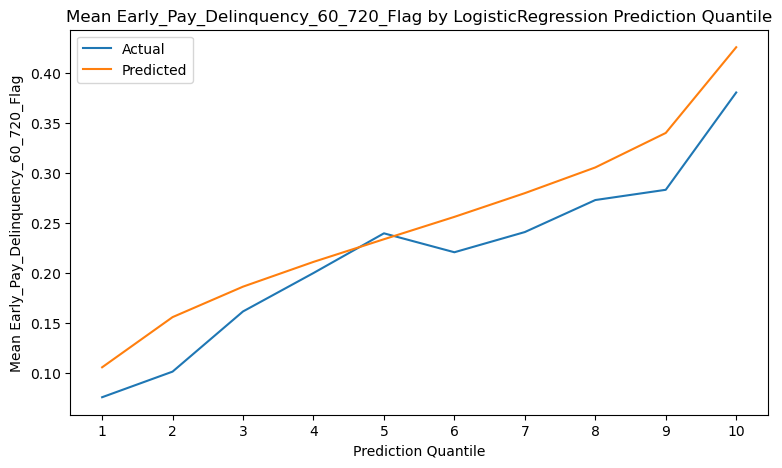

In [72]:
# mean actual by prediction quantile
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='LogisticRegression',
)

In [73]:
# # directions of predictions
# int_n_quantiles = 10
# get_directions_of_predictions(
#     X=X_holdout.copy(),
#     list_predictions=list_predictions_holdout,
#     str_target=str_target,
#     list_actual=list(y_holdout),
#     list_cols=list_cols_tmp,
#     int_n_quantiles=int_n_quantiles,
# )

#### Scorecard from logistic regression model (via ML)

In [74]:
dict_bins, list_cols_scorecard, X_train, X_test, X_holdout = bin_features(
    list_cols=list_cols_tmp,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    X_holdout=X_holdout,
    dict_monotone_constraints=dict_monotone_constraints,
)
# pickle dict_bins
str_filename = 'dict_bins.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(dict_bins, open(str_local_path, 'wb'))

100%|██████████| 21/21 [00:00<00:00, 29.31it/s]


In [75]:
# make sure every column has at least 2 bins
list_col_no_var = []
for col in tqdm(list_cols_scorecard):
    int_n_unique = X_train[col].nunique()
    # logic
    if int_n_unique < 2:
        list_col_no_var.append(col)
    else:
        pass
print(f'There are {len(list_col_no_var)} features with no variance after binning')
for a, col in enumerate(list_col_no_var):
    print(f'{a+1} - {col}')
# rm
list_cols_scorecard = [col for col in list_cols_scorecard if col not in list_col_no_var]
print(f'There are {len(list_cols_scorecard)} features available for scorecard inclusion')

100%|██████████| 21/21 [00:00<00:00, 3050.83it/s]

There are 2 features with no variance after binning
1 - s073b__tu_binned
2 - addrlastmovetaxratiodiff__ln_binned
There are 19 features available for scorecard inclusion


In [76]:
# show bins
df_tmp = X_train.copy()
df_tmp['target'] = y_train
list_df = []
for col in tqdm(list_cols_scorecard):
    # get 
    # get original column
    str_col_original = col.split('_binned')[0]
    # get min max and mean
    df_grouped = df_tmp.groupby(by=col, as_index=False).agg({
        str_col_original: ['min', 'max', 'count'],
        'target': 'mean',
    })
    # sort
    df_grouped.sort_values(by=(str_col_original, 'min'), ascending=True, inplace=True)
    df_grouped['feature'] = col
    # rename
    list_cols = ['bin','min','max','count','target','feature']
    df_grouped.columns = list_cols
    df_grouped['prop'] = df_grouped['count'] / df_grouped['count'].sum()
    # bin label
    df_grouped['bin_label'] = range(1, df_grouped.shape[0]+1)
    # reorder
    list_cols = ['feature','bin','min','max','count','prop','target','bin_label']
    df_grouped = df_grouped[list_cols].copy()
    # append
    list_df.append(df_grouped)

# make df
df_bins = pd.concat(list_df)

# save
str_filename = 'df_bins.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_bins.to_csv(str_local_path, index=False)

# show
df_bins

100%|██████████| 19/19 [00:00<00:00, 169.20it/s]


,feature,bin,min,max,count,prop,target,bin_label
4,dti__app_binned,0.321242,1.702548e-07,0.295007,1676,0.104515,0.214797,1
3,dti__app_binned,0.113476,2.950216e-01,0.322237,1838,0.114617,0.251904,2
2,dti__app_binned,0.017709,3.222463e-01,0.464380,9705,0.605201,0.270376,3
1,dti__app_binned,-0.031266,4.643953e-01,0.511499,1924,0.119980,0.280146,4
0,dti__app_binned,-0.793095,5.115531e-01,4.761776,893,0.055687,0.454647,5
...,...,...,...,...,...,...,...,...
3,flt_wtd_avg_closed__tu_pmthx_binned,0.204882,8.380952e-01,1.000000,4773,0.297643,0.235072,4
0,ENG-bk_binned,-0.078999,0.000000e+00,0.000000,13023,0.812110,0.289872,1
1,ENG-bk_binned,0.381681,1.000000e+00,1.000000,3013,0.187890,0.204779,2
1,addrinputtimenewest__ln_binned,0.080183,1.000000e+00,3.000000,11513,0.717947,0.258230,1


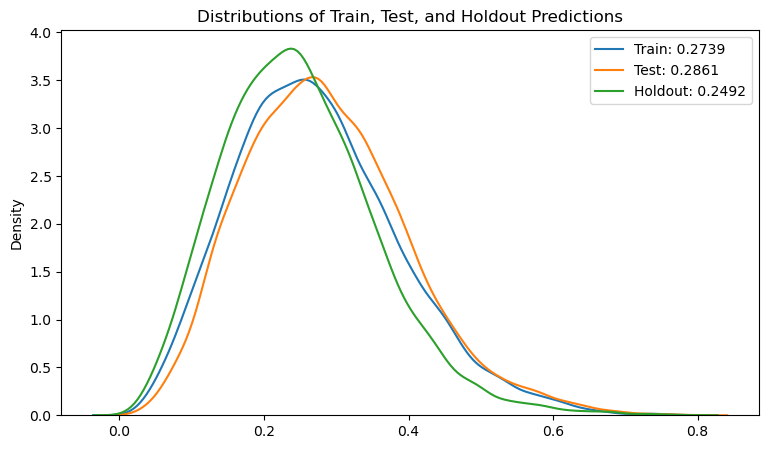

In [77]:
# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
)
# fit
cls_model_inference.fit(
    X_train[list_cols_scorecard],
    y_train,
)

# save
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(cls_model_inference, open(str_local_path, 'wb'))

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_scorecard])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [78]:
# eval
flt_auc_train = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6618
AUC Test: 0.6532
AUC Holdout: 0.6479

Logloss Train: 0.5528
Logloss Test: 0.5566
Logloss Holdout: 0.5018

KS Train: 0.2329
KS Test: 0.2142
KS Holdout: 0.1991


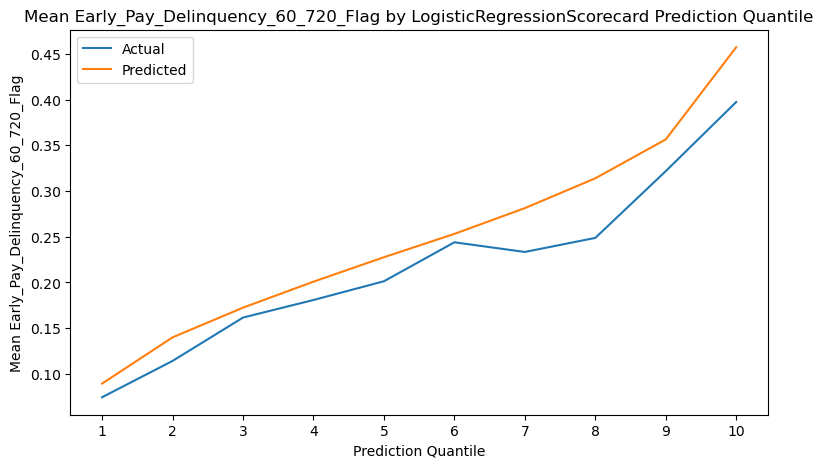

In [79]:
# mean actual by prediction quantile
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='LogisticRegressionScorecard',
)

In [80]:
# # directions of predictions
# int_n_quantiles = 10
# get_directions_of_predictions_for_scorecard(
#     X=X_holdout.copy(),
#     list_predictions=list_predictions_holdout,
#     str_target=str_target,
#     list_actual=list(y_holdout),
#     list_cols=list_cols_scorecard,
#     df_bins=df_bins,
# )

#### Sensitivity tuning

In [81]:
# starting target
flt_auc_train_start = flt_auc_train
# make copy
list_cols_start = list_cols_scorecard.copy()

list_feat_rm = []
list_dict_row_a = []
while True:
    list_dict_row_b = []
    # make sure the features have been removed
    list_cols_start = [col for col in list_cols_start if col not in list_feat_rm]
    # iterate through cols and remove one at a time with replacement
    for col_a in tqdm(list_cols_start):
        # rm col
        list_cols_scorecard_tmp = [col_b for col_b in list_cols_start if col_b != col_a]

        # init
        cls_model_inference = LogisticRegression(
            random_state=42,
            fit_intercept=True,
        )
        # fit
        cls_model_inference.fit(
            X_train[list_cols_scorecard_tmp].copy(),
            y_train,
        )

        # get predictions
        list_predictions_tmp = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard_tmp])[:,1])

        # get auc
        flt_score = skm.roc_auc_score(
            y_true=y_train,
            y_score=list_predictions_tmp,
        )
        # make row
        dict_row_b = {
            'feature': col_a,
            'score': flt_score,
            'target': flt_auc_train_start,
        }
        # append
        list_dict_row_b.append(dict_row_b)
    # make df
    df_tmp = pd.DataFrame(list_dict_row_b)
    
    # get diff
    df_tmp['diff'] = df_tmp['score'] - df_tmp['target']
    
    # make a copy
    df_sensitivity = df_tmp.copy()
    # sort
    df_sensitivity.sort_values(by='diff', ascending=True, inplace=True)
    # save
    str_filename = 'df_sensitivity.csv'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    df_sensitivity.to_csv(str_local_path, index=False)
    
    # only keep positive
    df_tmp = df_tmp[df_tmp['diff'] >= 0].copy()
    
    # get number of features that improved performance upon removal
    int_n_feats = df_tmp.shape[0]
    
    # logic
    if int_n_feats == 0:
        break
    else:
        pass
    
    # sort
    df_tmp.sort_values(by='diff', ascending=False, inplace=True)
    # get the feature that improves performance most upon removal
    str_feat_rm = df_tmp['feature'].iloc[0]
    # append
    list_feat_rm.append(str_feat_rm)
    # get score
    flt_score_rm = df_tmp['score'].iloc[0]
    # update the flt_auc_train_start
    flt_auc_train_start = flt_score_rm
    # get current target
    flt_target_rm = df_tmp['target'].iloc[0]
    # make row
    dict_row_a = {
        'feature': str_feat_rm,
        'score': flt_score_rm,
        'target': flt_target_rm,
    }
    # append
    list_dict_row_a.append(dict_row_a)
# make df
df_tmp = pd.DataFrame(list_dict_row_a)
# save
str_filename = 'df_sensitivity_tuning.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)
# show
df_tmp

100%|██████████| 19/19 [00:00<00:00, 30.93it/s]


""


In [82]:
# plot
try:
    x = df_tmp['feature']
    y = df_tmp['score']
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title('AUC by Feature Removed')
    ax.set_ylabel('AUC')
    ax.plot(x, y)
    ax.set_xticklabels(x, rotation=90)
    plt.show()
except KeyError:
    pass

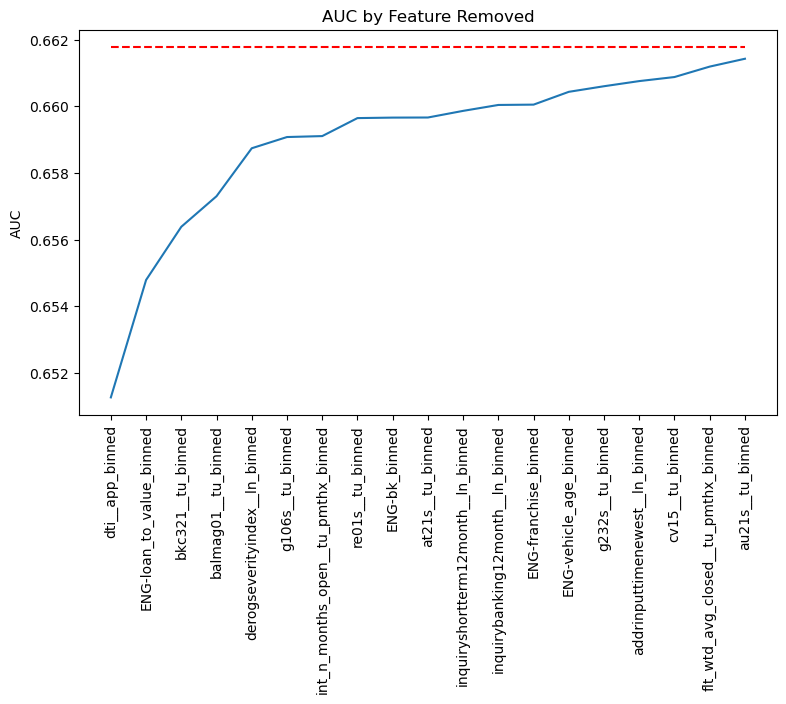

In [83]:
# plot
x = df_sensitivity['feature']
y = df_sensitivity['score']
z = df_sensitivity['target']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('AUC by Feature Removed')
ax.set_ylabel('AUC')
ax.plot(x, y)
ax.plot(x, z, linestyle='--', color='red')
ax.set_xticklabels(x, rotation=90)
plt.show()

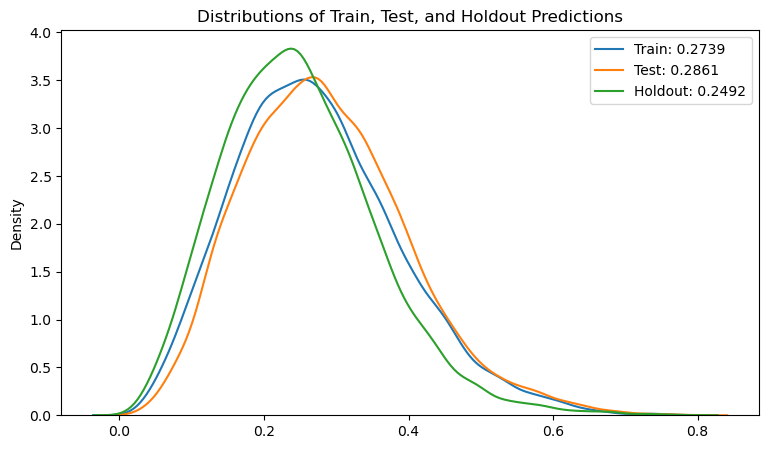

In [84]:
# rm
try:
    list_cols_rm = list(df_tmp['feature'])
    list_cols_scorecard = [col for col in list_cols_scorecard if col not in list_cols_rm]
except KeyError:
    pass

# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
)
# fit
cls_model_inference.fit(
    X_train[list_cols_scorecard].copy(),
    y_train,
)

# save
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(cls_model_inference, open(str_local_path, 'wb'))

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_scorecard])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [85]:
# eval
flt_auc_train = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6618
AUC Test: 0.6532
AUC Holdout: 0.6479

Logloss Train: 0.5528
Logloss Test: 0.5566
Logloss Holdout: 0.5018

KS Train: 0.2329
KS Test: 0.2142
KS Holdout: 0.1991


#### Get intercept

In [86]:
# get intercept
flt_intercept = cls_model_inference.intercept_[0]
print(f'Intercept: {flt_intercept}')

Intercept: -0.9758750429762694


In [87]:
# get feature importance
dict_map_descriptions_bin = {f'{key}_binned': val for key, val in dict_map_descriptions.items()}
df_tmp = get_logistic_regression_feat_importance(
    cls_model_inference=cls_model_inference,
    list_cols_model=list_cols_scorecard,
    df=X_test,
)
# map desceription
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions_bin)

# save
str_filename = 'df_feat_imp.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

,feature,importance,importance_abs,description
4,bkc321__tu_binned,-0.011877,0.011877,Min Total Open-to-Buy for Bankcard accounts ov...
0,dti__app_binned,0.010355,0.010355,NaN
6,re01s__tu_binned,-0.008777,0.008777,Number of revolving trades
14,ENG-vehicle_age_binned,0.007378,0.007378,NaN
17,ENG-bk_binned,0.006566,0.006566,NaN
7,int_n_months_open__tu_pmthx_binned,-0.006082,0.006082,NaN
3,g106s__tu_binned,-0.005857,0.005857,Months on file
10,cv15__tu_binned,-0.003725,0.003725,Number of deduped auto inquiries
15,at21s__tu_binned,0.003494,0.003494,Months since most recent trade opened
8,inquirybanking12month__ln_binned,0.002705,0.002705,Indicates subject has one or more LexisNexis b...


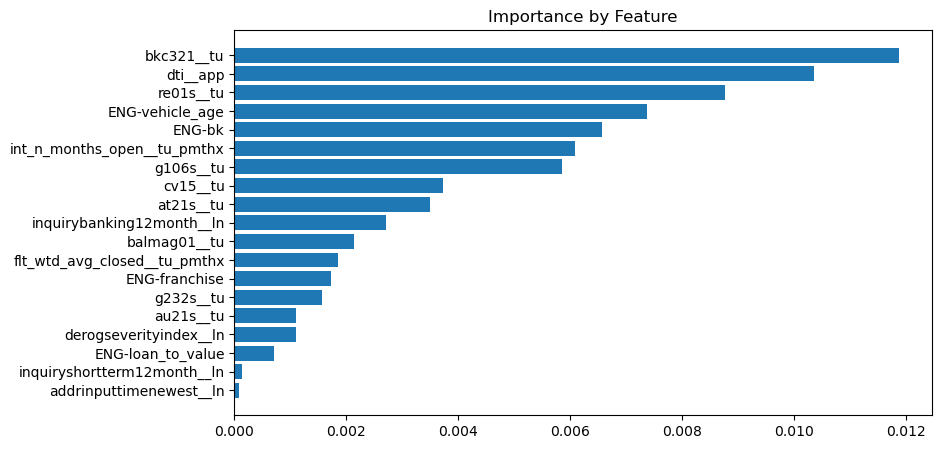

In [88]:
# plot
df_tmp.sort_values(by='importance_abs', ascending=True, inplace=True)
df_tmp['feature_tmp'] = df_tmp['feature'].apply(
    lambda x: x.split('_binned')[0],
)
x = df_tmp['feature_tmp']
y = df_tmp['importance_abs']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Importance by Feature')
ax.barh(x, y)
# show
plt.show()

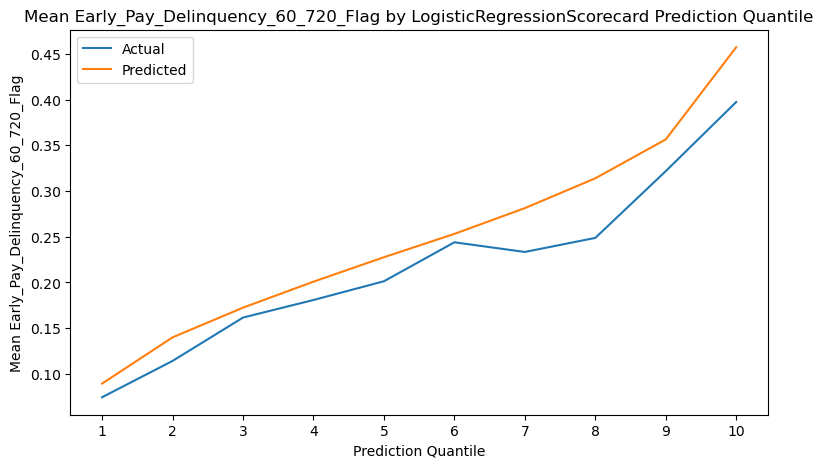

In [89]:
# mean actual by prediction quantile
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='LogisticRegressionScorecard',
)

  0%|          | 0/19 [00:00<?, ?it/s]

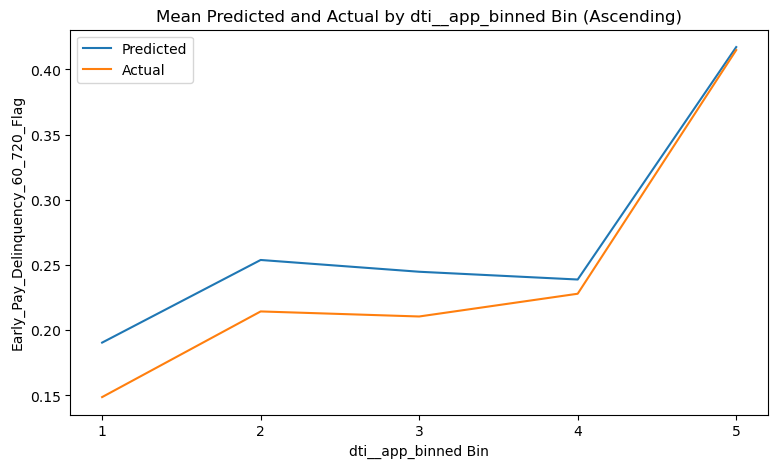

  5%|▌         | 1/19 [00:00<00:02,  7.24it/s]

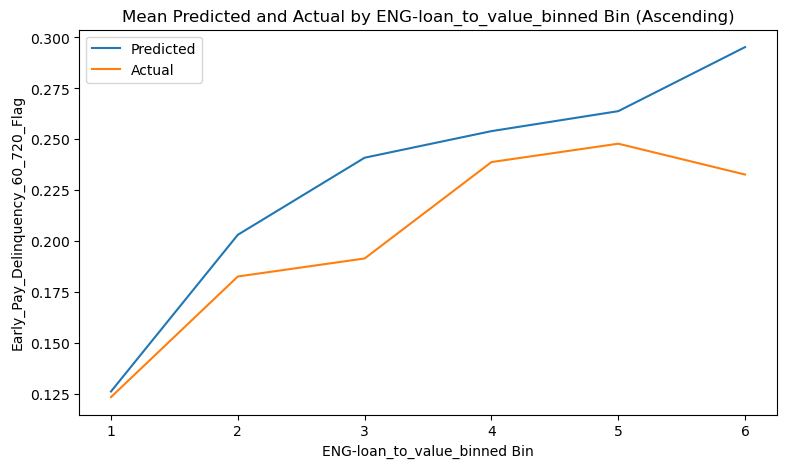

 11%|█         | 2/19 [00:00<00:02,  6.88it/s]

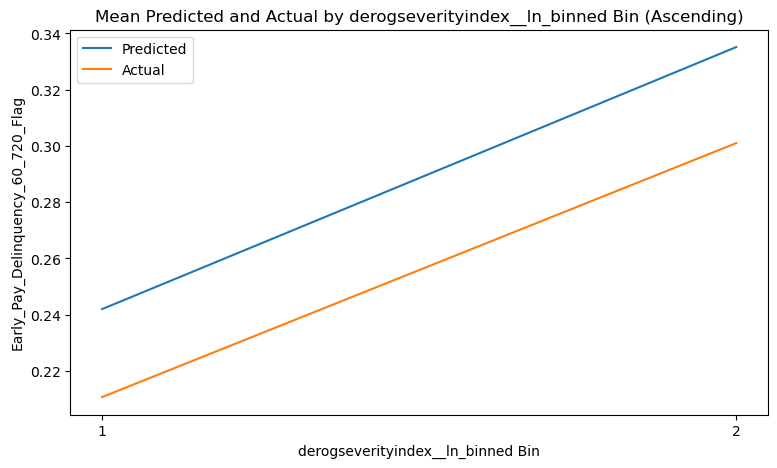

 16%|█▌        | 3/19 [00:00<00:02,  7.15it/s]

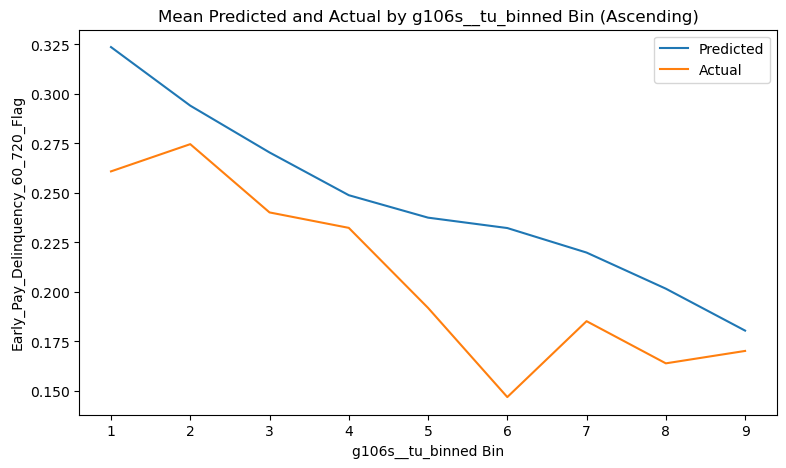

 21%|██        | 4/19 [00:00<00:02,  6.81it/s]

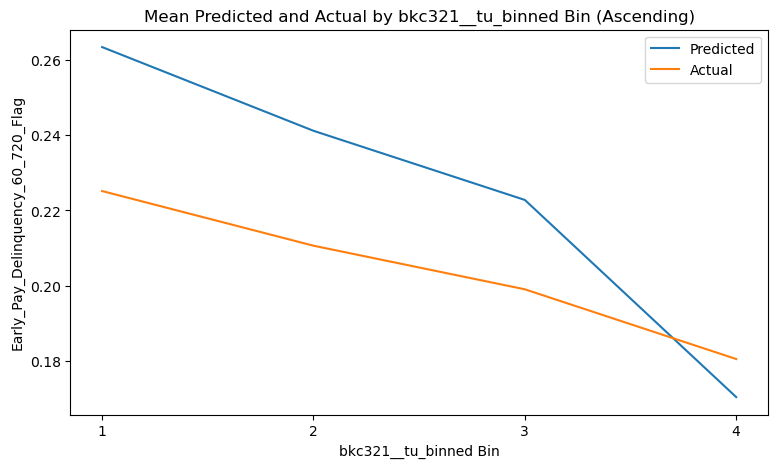

 26%|██▋       | 5/19 [00:00<00:01,  7.10it/s]

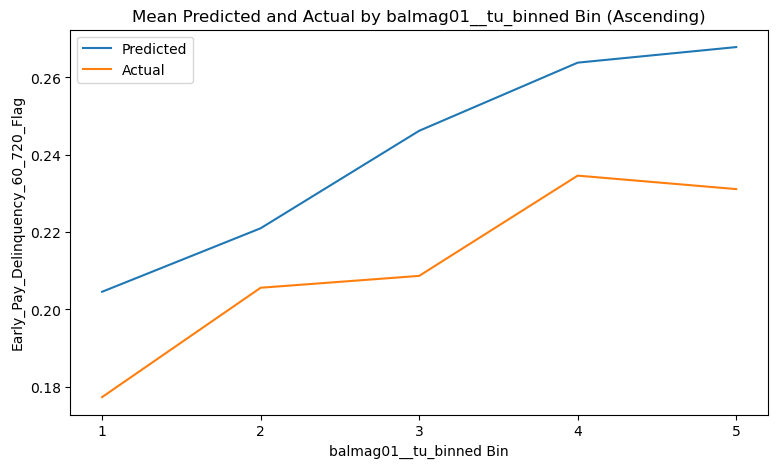

 32%|███▏      | 6/19 [00:00<00:01,  7.22it/s]

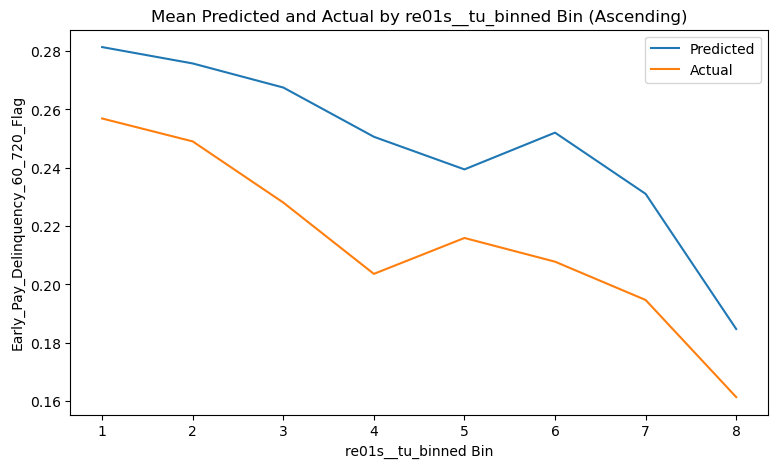

 37%|███▋      | 7/19 [00:01<00:02,  5.45it/s]

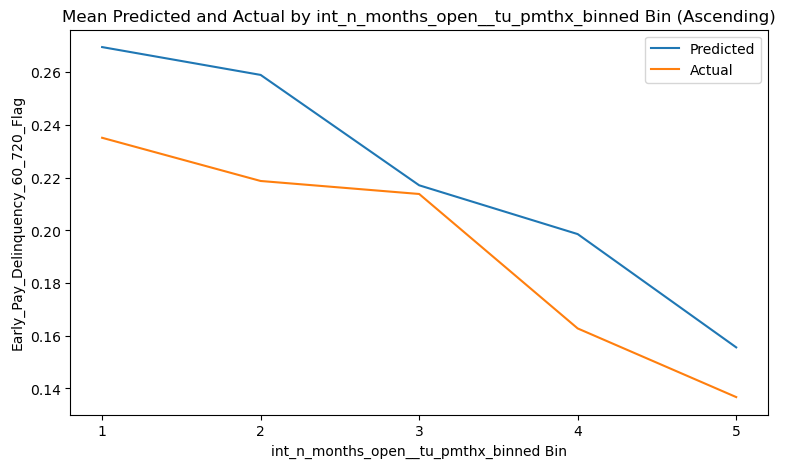

 42%|████▏     | 8/19 [00:01<00:01,  5.86it/s]

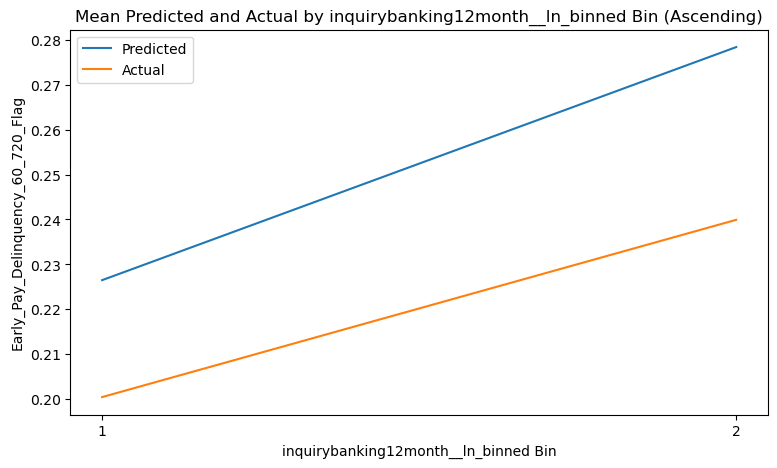

 47%|████▋     | 9/19 [00:01<00:01,  6.13it/s]

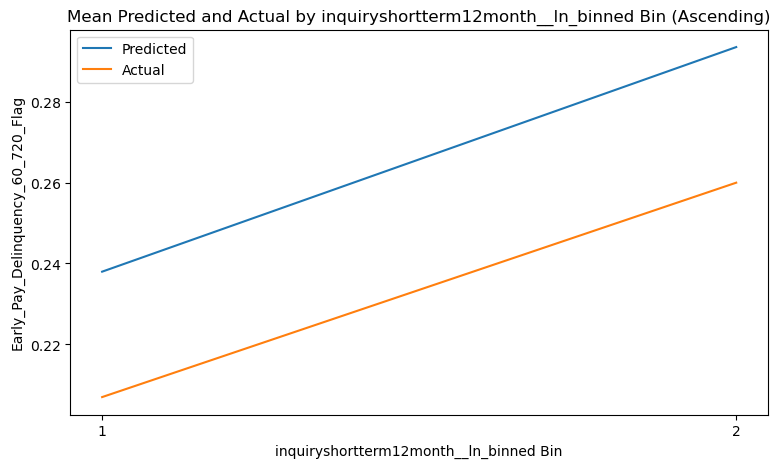

 53%|█████▎    | 10/19 [00:01<00:01,  6.57it/s]

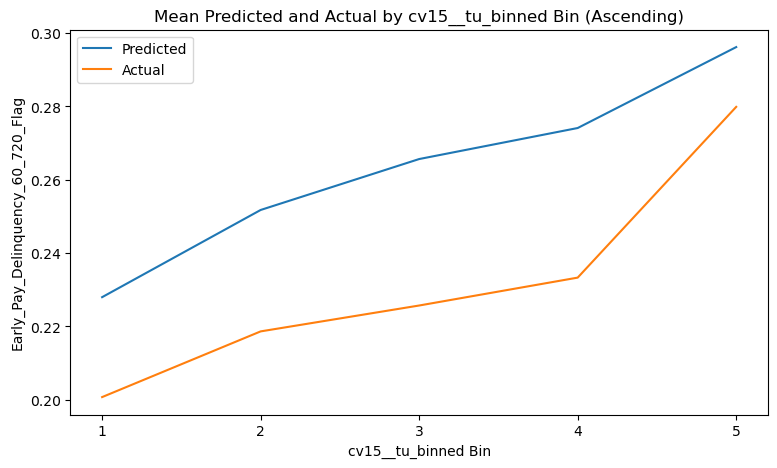

 58%|█████▊    | 11/19 [00:01<00:01,  6.72it/s]

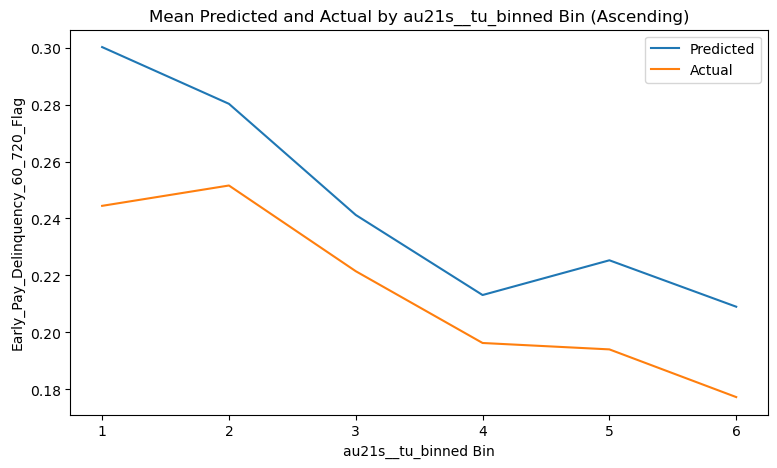

 63%|██████▎   | 12/19 [00:01<00:01,  6.69it/s]

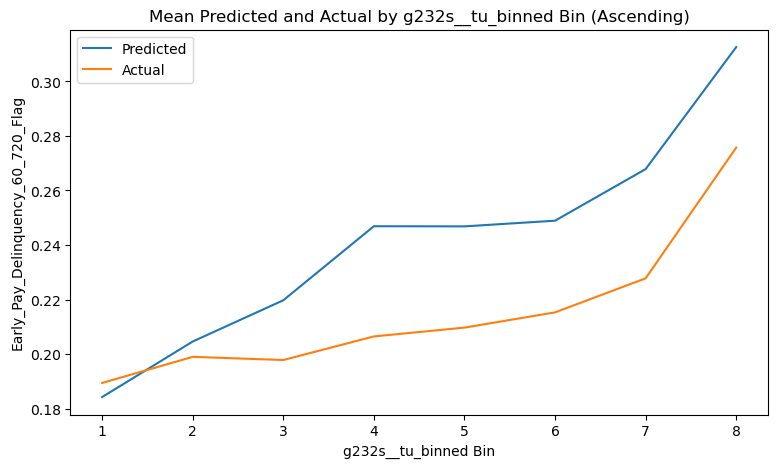

 68%|██████▊   | 13/19 [00:01<00:00,  6.59it/s]

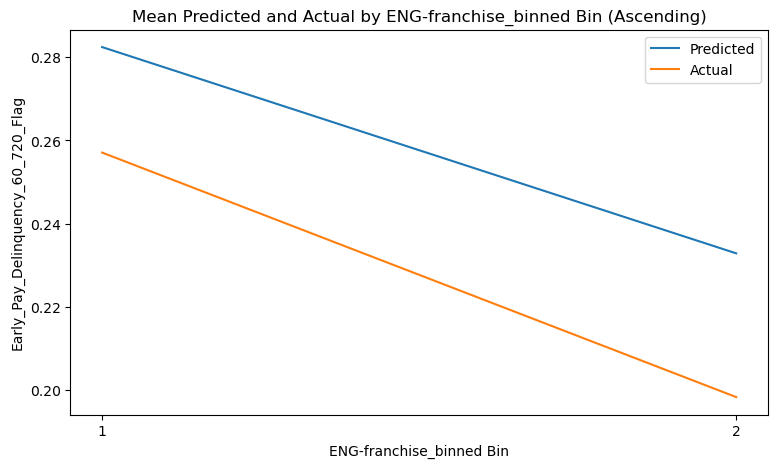

 74%|███████▎  | 14/19 [00:02<00:00,  6.91it/s]

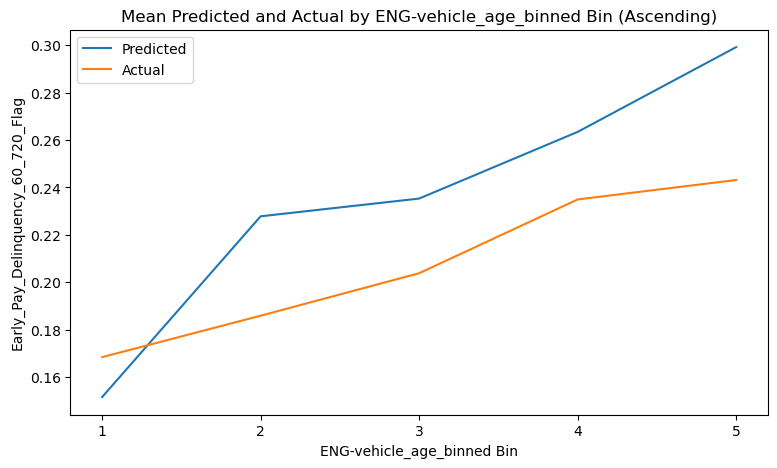

 79%|███████▉  | 15/19 [00:02<00:00,  6.81it/s]

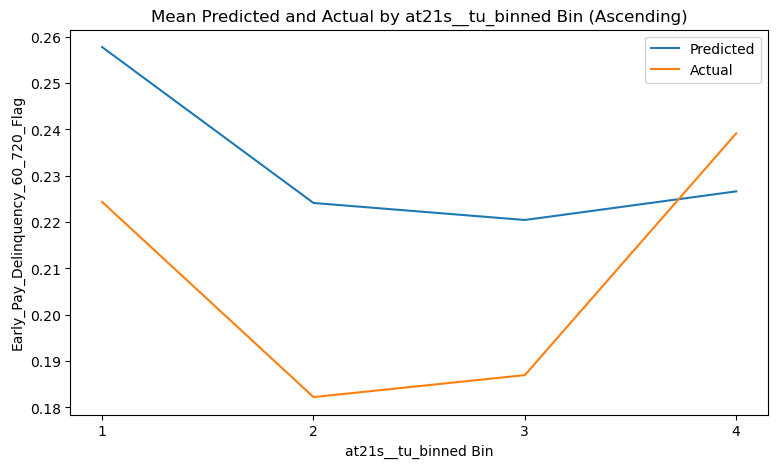

 84%|████████▍ | 16/19 [00:02<00:00,  6.74it/s]

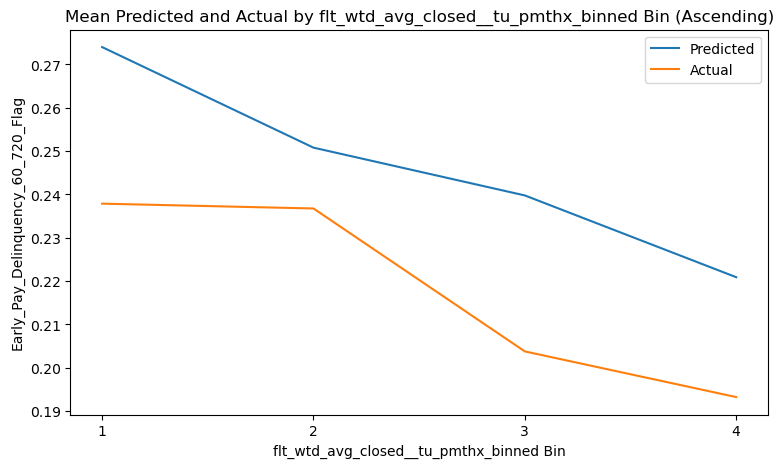

 89%|████████▉ | 17/19 [00:02<00:00,  6.65it/s]

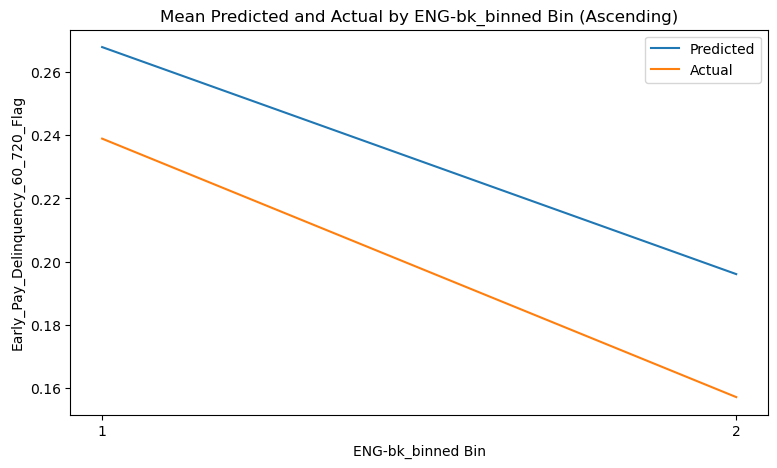

 95%|█████████▍| 18/19 [00:02<00:00,  6.94it/s]

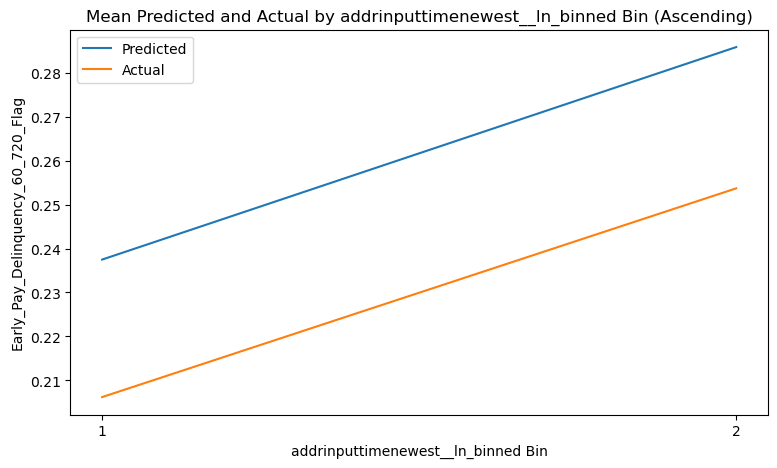

100%|██████████| 19/19 [00:02<00:00,  6.67it/s]


In [90]:
# directions of predictions
int_n_quantiles = 10
get_directions_of_predictions_for_scorecard(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    str_target=str_target,
    list_actual=list(y_holdout),
    list_cols=list_cols_scorecard,
    df_bins=df_bins,
)

#### What does the scorecard like?

In [91]:
# copy df_bins
df_identity = df_bins[df_bins['feature'].isin(list_cols_scorecard)].copy()

df_coef = pd.DataFrame({
    'feature': cls_model_inference.feature_names_in_,
    'coef': cls_model_inference.coef_[0],
})
# create dictionary
dict_map_coef = dict(zip(df_coef['feature'], df_coef['coef']))

# map to df_identity
df_identity['coef'] = df_identity['feature'].map(dict_map_coef)

# multiply by bin value
df_identity['contribution'] = df_identity['bin'] * df_identity['coef']

# sort
df_identity.sort_values(by=['feature','contribution'], ascending=[True,True], inplace=True)

# get description
df_identity['description'] = df_identity['feature'].map(dict_map_descriptions_bin)

# save
str_filename = 'df_scorecard.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_identity.to_csv(str_local_path, index=False)

# show
df_identity

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution,description
1,ENG-bk_binned,0.381681,1.000000,1.000000,3013,0.187890,0.204779,2,-0.714072,-0.272548,NaN
0,ENG-bk_binned,-0.078999,0.000000,0.000000,13023,0.812110,0.289872,1,-0.714072,0.056411,NaN
1,ENG-franchise_binned,0.100467,1.000000,1.000000,10599,0.660950,0.254364,2,-0.648367,-0.065139,NaN
0,ENG-franchise_binned,-0.183926,0.000000,0.000000,5437,0.339050,0.311937,1,-0.648367,0.119251,NaN
5,ENG-loan_to_value_binned,0.723279,0.185468,1.006807,821,0.051197,0.154689,1,-0.868174,-0.627932,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4,re01s__tu_binned,0.103872,4.000000,4.000000,1143,0.071277,0.253718,5,-0.617329,-0.064123,Number of revolving trades
3,re01s__tu_binned,0.051780,3.000000,3.000000,1532,0.095535,0.263708,4,-0.617329,-0.031965,Number of revolving trades
2,re01s__tu_binned,-0.030359,2.000000,2.000000,2136,0.133200,0.279963,3,-0.617329,0.018741,Number of revolving trades
1,re01s__tu_binned,-0.106299,1.000000,1.000000,2971,0.185271,0.295523,2,-0.617329,0.065622,Number of revolving trades


#### Show only the best one by feature

In [92]:
df_identity_sub = df_identity.drop_duplicates(subset=['feature'], keep='first', inplace=False)

# sort
df_identity_sub.sort_values(by='contribution', ascending=True, inplace=True)

# save
str_filename = 'df_scorecard_sub.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_identity_sub.to_csv(str_local_path, index=False)

# show
df_identity_sub

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution,description
5,ENG-loan_to_value_binned,0.723279,1.854683e-01,1.006807,821,0.051197,0.154689,1,-0.868174,-0.627932,NaN
3,bkc321__tu_binned,0.509577,1.720000e+02,45840.000000,1402,0.087428,0.184736,4,-1.038008,-0.528945,Min Total Open-to-Buy for Bankcard accounts ov...
4,ENG-vehicle_age_binned,0.704275,-1.000000e+00,0.000000,897,0.055937,0.157191,1,-0.579989,-0.408472,NaN
4,int_n_months_open__tu_pmthx_binned,0.634432,4.400000e+01,82.000000,1044,0.065104,0.166667,5,-0.554710,-0.351926,NaN
3,at21s__tu_binned,0.296625,6.800000e+01,379.000000,959,0.059803,0.218978,4,-1.164022,-0.345278,Months since most recent trade opened
4,dti__app_binned,0.321242,1.702548e-07,0.295007,1676,0.104515,0.214797,1,-0.969519,-0.311450,NaN
4,balmag01__tu_binned,0.274415,0.000000e+00,158.000000,2114,0.131828,0.222800,1,-1.090419,-0.299227,Non-mortgage balance magnitude algorithm over ...
7,re01s__tu_binned,0.457146,9.000000e+00,50.000000,1603,0.099963,0.192764,8,-0.617329,-0.282209,Number of revolving trades
8,g106s__tu_binned,0.543941,4.310000e+02,768.000000,991,0.061798,0.179617,9,-0.506288,-0.275391,Months on file
1,ENG-bk_binned,0.381681,1.000000e+00,1.000000,3013,0.187890,0.204779,2,-0.714072,-0.272548,NaN


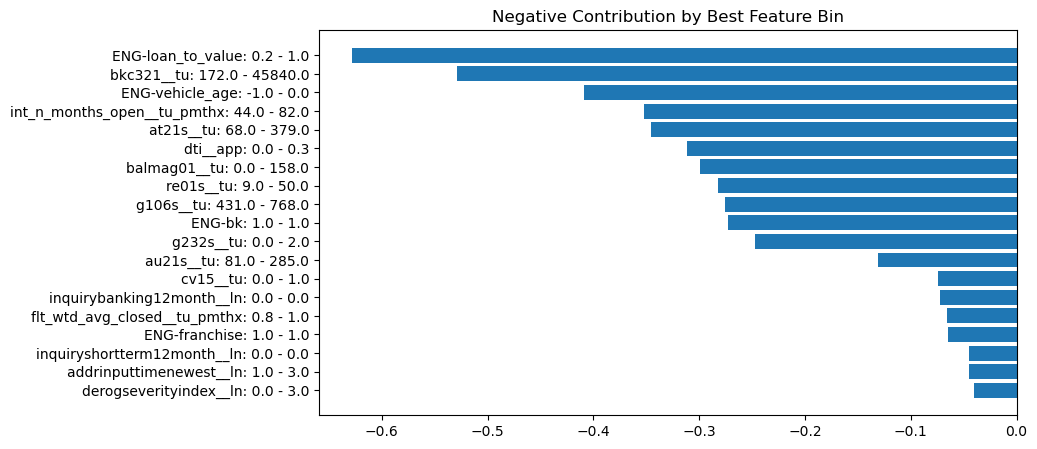

In [93]:
# plot
df_identity_sub['label'] = df_identity_sub.apply(
    lambda x: f"{x['feature'].split('_binned')[0]}: {x['min']:0.1f} - {x['max']:0.1f}",
    axis=1,
)

# plot
df_identity_sub.sort_values(by='contribution', ascending=False, inplace=True)
x = df_identity_sub['label']
y = df_identity_sub['contribution']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Negative Contribution by Best Feature Bin')
ax.barh(x, y)
# show
plt.show()